# InverseRL1 May 9 MultiFund CLEAN No-Leakage Results

This notebook keeps the May 9 multifund pipeline but removes leakage from the model section. Run top-to-bottom. The important fixed-split outputs are `clean_summary` and `clean_multi`; rolling outputs are `clean_rolling_df` and `rolling_summary`.

Clean rules:
- IRL trains only on the current train window.
- AR(1) is estimated only on train returns.
- V1/V2/V3 fixed split train on all available returns except the last 4, then test on those last 4 returns.
- Rolling walk-forward is separate: V3 trains on q1..q8 / tests q9, then q1..q9 / tests q10, etc.


In [1]:
# ───────────────────────── EDIT THIS BLOCK FOR YOUR OWN RUN ─────────────────
# Path to rebellion.py (data extractor in your Scripts folder).
MODULE_PATH = "/Users/farhanrashid/Library/Mobile Documents/com~apple~CloudDocs/Rebellion_Raw_data/Scripts/rebellion.py"

ENV = "local"   # do not change — this notebook is the VS Code / local edition

# Date range — 2020-01-01 → 2025-12-31 ≈ 24 quarterly filings per fund
START_DATE  = "2015-01-01"
END_DATE    = "2025-12-31"
TEST_CUTOFF = "2024-01-01"   # used by the v3 fixed walk-forward (Step 12)

# Funds — add/remove rows. CIK must be 10-digit zero-padded.
# (Names match EDGAR's canonical company name; rebellion.py uses the CIK directly.)
FUNDS = [
    {"cik": "0001079114", "name": "GREENLIGHT CAPITAL INC"},                  # David Einhorn
    {"cik": "0001336528", "name": "Pershing Square Capital Management, L.P."},  # Bill Ackman
    {"cik": "0001791786", "name": "Elliott Investment Management L.P."},                         # Daniel Loeb
    {"cik": "0001656456", "name": "APPALOOSA LP"},                            # David Tepper
    {"cik": "0001061768", "name": "BAUPOST GROUP LLC/MA"},                    # Seth Klarman
]

# IRL training
IRL_EPOCHS      = 1000
IRL_LR          = 0.01
IRL_MAX_WINDOWS = 100

# PPO budgets per fund. Drop these (e.g. 50_000) for fast plumbing tests.
TIMESTEPS_V1 = 200_000
TIMESTEPS_V2 = 200_000
TIMESTEPS_V3 = 500_000

# Rolling walk-forward (Step 14).
MIN_TRAIN_QUARTERS = 12          # first test = quarter 13 → up to 12 test obs / fund (24q hist)
TIMESTEPS_ROLLING  = 100_000     # PPO steps per rolling-step retrain

# Misc
N_PARALLEL_ENVS  = 4
N_SIM_STEPS      = 64
SEED             = 42
MAX_W_PER_SECTOR = 0.30
USE_EXCESS_RETS  = True

# Unit-normalisation absolute threshold: 13F requires ≥$100M AUM, so any fund with
# median per-filing total below $50M is almost certainly reporting in $1000s.
AUM_THRESHOLD_USD = 50_000_000

# SEC fetch retry
MAX_DOWNLOAD_RETRIES = 3
RETRY_BACKOFF_S      = 8.0       # 8s → 16s → 32s

print(f"Funds: {len(FUNDS)}")
print(f"Date range: {START_DATE} → {END_DATE}")
print(f"v3 fixed-split cutoff: {TEST_CUTOFF}")
print(f"Rolling walk-forward: train q1..k / test q(k+1) for k = {MIN_TRAIN_QUARTERS}..T-2")
print(f"PPO steps per fund: v1={TIMESTEPS_V1:,} + v2={TIMESTEPS_V2:,} + v3={TIMESTEPS_V3:,}")
print(f"PPO steps per rolling step: {TIMESTEPS_ROLLING:,}")
# ─────────────────────────────────────────────────────────────────────────────

Funds: 5
Date range: 2015-01-01 → 2025-12-31
v3 fixed-split cutoff: 2024-01-01
Rolling walk-forward: train q1..k / test q(k+1) for k = 12..T-2
PPO steps per fund: v1=200,000 + v2=200,000 + v3=500,000
PPO steps per rolling step: 100,000


In [2]:
import os, importlib.util, sys

if os.path.isfile(MODULE_PATH):
    spec = importlib.util.spec_from_file_location("rebellion", MODULE_PATH)
    data = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(data)
    print(f"Loaded rebellion.py from {MODULE_PATH}")
else:
    raise FileNotFoundError(
        f"Could not find rebellion.py at {MODULE_PATH}. Edit MODULE_PATH in the CONFIG cell.")

Loaded rebellion.py from /Users/farhanrashid/Library/Mobile Documents/com~apple~CloudDocs/Rebellion_Raw_data/Scripts/rebellion.py


In [3]:
# Install only if missing — uses lxml.etree (the C-extension, what BS4 actually needs)
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "--force-reinstall", "--no-cache-dir", pkg])

for pkg, imp in [("torch", "torch"),
                 ("lxml", "lxml.etree"),       # rebellion.py uses BeautifulSoup(..., 'lxml')
                 ("yfinance", "yfinance"),
                 ("rapidfuzz", "rapidfuzz"),
                 ("stable_baselines3", "stable_baselines3"),
                 ("shimmy", "shimmy"),
                 ("gymnasium", "gymnasium"),
                 ("seaborn", "seaborn"),
                 ("beautifulsoup4", "bs4")]:
    _ensure(pkg, imp)
print("dependencies ok")

dependencies ok


In [4]:
import pandas as pd
import time as _time

def _download_with_retry(fund, start, end,
                         max_retries=MAX_DOWNLOAD_RETRIES, backoff=RETRY_BACKOFF_S):
    """Wraps rebellion.download_13f_in_date_range with retries.
    Backs off geometrically (8s → 16s → 32s) so SEC throttle has time to clear."""
    company = pd.Series({"CIK": fund["cik"], "Company Name": fund["name"]})
    df = pd.DataFrame()
    for attempt in range(max_retries):
        if attempt > 0:
            wait = backoff * (2 ** (attempt - 1))
            print(f"  retry {attempt}/{max_retries-1} after {wait:.0f}s backoff…")
            _time.sleep(wait)
        try:
            df = data.download_13f_in_date_range(
                start_date=start, end_date=end, data=company, save=False)
        except Exception as e:
            print(f"  FETCH ERROR (attempt {attempt+1}): {e}")
            df = pd.DataFrame()
        if not df.empty:
            return df
    return df

fund_dfs = {}
for f in FUNDS:
    print(f"\n─── Downloading {f['name']} (CIK {f['cik']}) {START_DATE} → {END_DATE} ───")
    df_f = _download_with_retry(f, START_DATE, END_DATE)
    n_dates = df_f['filing_date'].nunique() if len(df_f) else 0
    print(f"  rows: {len(df_f):,}    unique filing_dates: {n_dates}")
    if df_f.empty:
        print(f"  WARNING: 0 rows returned for {f['name']}.")
        print(f"  Check: https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany&CIK={f['cik']}&type=13F-HR")
    fund_dfs[f["cik"]] = df_f
    _time.sleep(0.5)   # be polite between funds


─── Downloading GREENLIGHT CAPITAL INC (CIK 0001079114) 2015-01-01 → 2025-12-31 ───

Looking up CIK for: GREENLIGHT CAPITAL INC
Success: CIK found: 0001079114

Fetching 13F-HR filings from 2015-01-01 to 2025-12-31...

https://www.sec.gov/Archives/edgar/data/1079114/000117266124001512/infotable.xml


/Users/farhanrashid/Library/Mobile Documents/com~apple~CloudDocs/Rebellion_Raw_data/Scripts/rebellion.py:73: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(r.content, 'lxml')



https://www.sec.gov/Archives/edgar/data/1079114/000117266123004012/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266123003174/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266123002282/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266123001336/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266122002565/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266122002019/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266122001474/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266122000884/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266121002370/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266121001874/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266121001325/infotable.xml

https://www.sec.gov/Archives/edgar/data/1079114/000117266121000770/infotable.xml

https://www.sec

/Users/farhanrashid/Library/Mobile Documents/com~apple~CloudDocs/Rebellion_Raw_data/Scripts/rebellion.py:73: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(r.content, 'lxml')



https://www.sec.gov/Archives/edgar/data/1336528/000117266125003509/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266125002315/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266125001119/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266124005218/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266124003511/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266124002519/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266124001556/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266123004016/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266123003137/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266123002303/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266123000673/infotable.xml

https://www.sec.gov/Archives/edgar/data/1336528/000117266122002568/infotable.xml

https://www.sec

...


https://www.sec.gov/Archives/edgar/data/1791786/000101359425001045/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359425000678/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359425000294/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359424000968/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359424000660/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359424000480/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359424000185/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359423000925/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359423000693/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359423000490/informationtable.xml

https://www.sec.gov/Archives/edgar/data/1791786/000101359423000244/informationtable.xml

https://www.sec.gov/

/Users/farhanrashid/Library/Mobile Documents/com~apple~CloudDocs/Rebellion_Raw_data/Scripts/rebellion.py:73: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(r.content, 'lxml')



https://www.sec.gov/Archives/edgar/data/1656456/000165645625000006/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645625000005/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645625000001/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645624000004/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645624000003/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645624000002/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645624000001/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645623000004/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645623000003/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645623000002/Form13FInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1656456/000165645623000001/Form13FInfoTable.xml

https://www.sec.gov/

/Users/farhanrashid/Library/Mobile Documents/com~apple~CloudDocs/Rebellion_Raw_data/Scripts/rebellion.py:73: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(r.content, 'lxml')



https://www.sec.gov/Archives/edgar/data/1061768/000106176825000005/bgllcq22025.xml

https://www.sec.gov/Archives/edgar/data/1061768/000106176825000003/bgllcq12025.xml

https://www.sec.gov/Archives/edgar/data/1061768/000106176825000002/bgllcq42024.xml

https://www.sec.gov/Archives/edgar/data/1061768/000106176824000005/BGLLCQ32024.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761924000363/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761924000317/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761924000192/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761923007709/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761923006910/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761923006061/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/1061768/000156761923002543/form13fInfoTable.xml

https://www.sec.gov/Archives/edgar/data/

In [5]:
import numpy as np

DATE_COL  = "filing_date"
VALUE_COL = "value"

for cik, df_f in fund_dfs.items():
    name = next(f["name"] for f in FUNDS if f["cik"] == cik)
    if df_f.empty:
        print(f"{name:<45} (no rows — SKIPPED)")
        continue

    df_u = df_f.copy()
    df_u[DATE_COL]  = pd.to_datetime(df_u[DATE_COL])
    df_u[VALUE_COL] = pd.to_numeric(df_u[VALUE_COL], errors='coerce').fillna(0.0)

    g = df_u.groupby(DATE_COL)[VALUE_COL].sum().sort_index()
    print(f"\n=== {name} ===")

    # --- Tier 1: bimodal split ---
    logv = np.log10(g.values + 1e-9)
    median = np.median(logv)
    low_mask, high_mask = logv < median, logv >= median
    gap = (logv[high_mask].mean() - logv[low_mask].mean()) if (low_mask.any() and high_mask.any()) else 0.0
    print(f"  Tier 1 (bimodal):       gap log10 = {gap:.2f}  (>2 ⇒ ~100x scale jump)")

    method = None
    if gap > 2.0:
        scale_dates = g.index[low_mask]
        method = f"BIMODAL → flagged {len(scale_dates)} low-group dates"
    else:
        # --- Tier 2: consecutive jump ---
        ratio = g.iloc[1:].values / (g.iloc[:-1].values + 1e-12)
        max_ratio = float(ratio.max()) if len(ratio) else 1.0
        print(f"  Tier 2 (jump>100x):     max consecutive ratio = {max_ratio:.2f}")
        jump = np.where(ratio > 100)[0]
        if len(jump):
            scale_dates = g.index[: jump[0] + 1]
            method = f"JUMP → flagged first {len(scale_dates)} dates (pre-jump)"
        else:
            # --- Tier 3: absolute threshold ---
            median_total = float(g.median())
            print(f"  Tier 3 (abs threshold): median per-filing total = ${median_total:,.0f}  "
                  f"(threshold = ${AUM_THRESHOLD_USD:,.0f})")
            if median_total < AUM_THRESHOLD_USD:
                scale_dates = g.index   # ALL dates
                method = f"ABS THRESHOLD → flagged ALL {len(scale_dates)} dates as $1000s"
            else:
                scale_dates = []
                method = "no rescaling — data appears to already be in raw USD"
    print(f"  Decision: {method}")

    if len(scale_dates):
        df_u.loc[df_u[DATE_COL].isin(scale_dates), VALUE_COL] *= 1000.0

    # Sanity check after rescaling
    g_fixed = df_u.groupby(DATE_COL)[VALUE_COL].sum().sort_index()
    if len(g_fixed) > 1:
        ratio_fixed = g_fixed.iloc[1:].values / (g_fixed.iloc[:-1].values + 1e-12)
        print(f"  Max consecutive jump after fix: {float(ratio_fixed.max()):.2f}x")
    print(f"  AUM range after fix:  ${g_fixed.min():,.0f}  →  ${g_fixed.max():,.0f}")

    fund_dfs[cik] = df_u


=== GREENLIGHT CAPITAL INC ===
  Tier 1 (bimodal):       gap log10 = 1.27  (>2 ⇒ ~100x scale jump)
  Tier 2 (jump>100x):     max consecutive ratio = 1022.80
  Decision: JUMP → flagged first 32 dates (pre-jump)
  Max consecutive jump after fix: 1.36x
  AUM range after fix:  $701,952,000  →  $7,973,888,000

=== Pershing Square Capital Management, L.P. ===
  Tier 1 (bimodal):       gap log10 = 1.89  (>2 ⇒ ~100x scale jump)
  Tier 2 (jump>100x):     max consecutive ratio = 1115.14
  Decision: JUMP → flagged first 32 dates (pre-jump)
  Max consecutive jump after fix: 1.24x
  AUM range after fix:  $4,832,044,000  →  $16,042,727,000

=== Elliott Investment Management L.P. ===
  Tier 1 (bimodal):       gap log10 = 3.20  (>2 ⇒ ~100x scale jump)
  Decision: BIMODAL → flagged 11 low-group dates
  Max consecutive jump after fix: 1.70x
  AUM range after fix:  $5,394,959,000  →  $22,721,159,137

=== APPALOOSA LP ===
  Tier 1 (bimodal):       gap log10 = 2.01  (>2 ⇒ ~100x scale jump)
  Decision: BIM

In [6]:
# Sanity peek — print column list of first non-empty fund (matches main script's df.columns cell)
for cik, df_f in fund_dfs.items():
    if not df_f.empty:
        print(f"Sample columns from {next(f['name'] for f in FUNDS if f['cik']==cik)}:")
        print(list(df_f.columns))
        break

Sample columns from GREENLIGHT CAPITAL INC:
['Company Name', 'CIK', 'nameOfIssuer', 'cusip', 'value', 'shares', 'shareType', 'putCall', 'investmentDiscretion', 'votingAuthoritySole', 'votingAuthorityShared', 'votingAuthorityNone', 'filing_date', 'filing_url']


In [7]:
import re, time, requests
import yfinance as yf
from rapidfuzz import fuzz, process

HEADERS = {"User-Agent": "Research Project research@example.com"}

# 1) Download SEC company list
url = "https://www.sec.gov/files/company_tickers.json"
js = requests.get(url, headers=HEADERS, timeout=20).json()
sec = pd.DataFrame([{"cik": str(v["cik_str"]).zfill(10), "ticker": v["ticker"], "name": v["title"]}
                    for v in js.values()])

def norm_name(s):
    s = re.sub(r"[^A-Za-z0-9 ]+", " ", str(s)).upper()
    s = re.sub(r"\b(CORP(ORATION)?|INC(ORPORATED)?|LTD|LLC|LP|PLC|CO|COMPANY|HLDGS?|HOLDINGS?)\b", " ", s)
    return re.sub(r"\s+", " ", s).strip()

sec["name_norm"] = sec["name"].apply(norm_name)

# 2) union all issuers across funds
all_issuers = pd.concat(
    [df_f[["cusip", "nameOfIssuer"]] for df_f in fund_dfs.values() if not df_f.empty],
    ignore_index=True,
).drop_duplicates()
all_issuers["name_norm"] = all_issuers["nameOfIssuer"].apply(norm_name)
print(f"Unique issuers across all funds: {len(all_issuers):,}")

# 3) exact-name merge then fuzzy match
m = all_issuers.merge(sec[["ticker", "name_norm"]], on="name_norm", how="left")
exact_matches = m["ticker"].notna().sum()
print(f"  exact name matches:  {exact_matches:,}")

unmatched = m[m["ticker"].isna()]
if not unmatched.empty:
    choices = sec[["name_norm", "ticker"]].drop_duplicates()
    for i, row in unmatched.iterrows():
        match = process.extractOne(row["name_norm"], choices["name_norm"], scorer=fuzz.token_sort_ratio)
        if match and match[1] >= 90:
            hit = choices[choices["name_norm"] == match[0]].iloc[0]
            m.at[i, "ticker"] = hit["ticker"]
fuzzy_added = m["ticker"].notna().sum() - exact_matches
print(f"  fuzzy matches (≥90): +{fuzzy_added:,}")
print(f"  TOTAL with ticker:   {m['ticker'].notna().sum():,} / {len(all_issuers):,}")

# 4) Yahoo sector lookup per ticker
def yf_sector(tk):
    try:
        return yf.Ticker(tk).get_info().get("sector")
    except Exception:
        return None

print("\nFetching sectors from Yahoo Finance (one-time)…")
tickers_to_fetch = m["ticker"].dropna().drop_duplicates()
sector_cache = {}
for tk in tickers_to_fetch:
    sector_cache[tk] = yf_sector(tk)
    time.sleep(0.15)
m["sector_raw"] = m["ticker"].map(sector_cache)
print(f"  yfinance sector returned for: {m['sector_raw'].notna().sum():,} / {len(tickers_to_fetch):,} tickers")

# 5) map to GICS-11
map_to_gics = {
    "Energy":"Energy","Materials":"Materials","Industrials":"Industrials",
    "Consumer Cyclical":"Consumer Discretionary","Consumer Defensive":"Consumer Staples",
    "Healthcare":"Health Care","Financial Services":"Financials",
    "Technology":"Information Technology","Communication Services":"Communication Services",
    "Utilities":"Utilities","Real Estate":"Real Estate",
}
m["sector"] = m["sector_raw"].map(map_to_gics).fillna(m["sector_raw"])

sector_map = (m.dropna(subset=["sector"])
                .groupby("cusip")["sector"]
                .agg(lambda s: s.value_counts().idxmax())
                .reset_index())
print(f"\nFinal sector_map covers {len(sector_map):,} unique CUSIPs")
sector_map.head()

Unique issuers across all funds: 950
  exact name matches:  498
  fuzzy matches (≥90): +41
  TOTAL with ticker:   539 / 950

Fetching sectors from Yahoo Finance (one-time)…


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MPLXP"}}}


  yfinance sector returned for: 496 / 449 tickers

Final sector_map covers 381 unique CUSIPs


,cusip,sector
0,00187Y100,Industrials
1,00206R102,Communication Services
2,00217D100,Information Technology
3,002896207,Consumer Discretionary
4,00724F101,Information Technology


In [8]:
coverage_rows = []
cutoff = pd.to_datetime(TEST_CUTOFF)
for f in FUNDS:
    cik = f["cik"]; df_f = fund_dfs.get(cik, pd.DataFrame())
    if df_f.empty:
        coverage_rows.append({"fund": f["name"], "rows": 0, "first_filing": "—",
                              "last_filing": "—", "n_filing_dates": 0, "n_post_cutoff": 0})
        continue
    df_f = df_f.copy(); df_f["filing_date"] = pd.to_datetime(df_f["filing_date"])
    coverage_rows.append({
        "fund": f["name"],
        "rows": len(df_f),
        "first_filing":  df_f["filing_date"].min().date(),
        "last_filing":   df_f["filing_date"].max().date(),
        "n_filing_dates": df_f["filing_date"].nunique(),
        "n_post_cutoff": df_f.loc[df_f["filing_date"] >= cutoff, "filing_date"].nunique(),
    })
print("=== 13F coverage per fund ===")
print(pd.DataFrame(coverage_rows).to_string(index=False))

=== 13F coverage per fund ===
                                    fund  rows first_filing last_filing  n_filing_dates  n_post_cutoff
                  GREENLIGHT CAPITAL INC  4289   2015-02-13  2024-02-14              37              1
Pershing Square Capital Management, L.P.   348   2015-02-17  2025-11-14              44              8
      Elliott Investment Management L.P.  1140   2020-05-15  2025-11-14              23              8
                            APPALOOSA LP  1530   2016-05-13  2025-11-13              39              8
                    BAUPOST GROUP LLC/MA  1474   2015-02-13  2024-08-13              39              3


In [9]:
import numpy as np
import pandas as pd
import torch
import yfinance as yf
import re

GICS_ORDER = [
    "Energy","Materials","Industrials","Consumer Discretionary","Consumer Staples",
    "Health Care","Financials","Information Technology","Communication Services",
    "Utilities","Real Estate",
]
SECTOR_TICKERS = {
    "Energy":"XLE","Materials":"XLB","Industrials":"XLI","Consumer Discretionary":"XLY",
    "Consumer Staples":"XLP","Health Care":"XLV","Financials":"XLF","Information Technology":"XLK",
    "Communication Services":"XLC","Utilities":"XLU","Real Estate":"XLRE",
}

def _to_gics_name(s):
    if pd.isna(s): return None
    if isinstance(s,(int,np.integer)) and 0<=int(s)<11:
        return GICS_ORDER[int(s)]
    s = re.sub(r'\s+',' ',str(s)).strip().lower()
    for name in GICS_ORDER:
        if s == name.lower(): return name
    return None

def _nearest(idx, target):
    pos = idx.searchsorted(pd.to_datetime(target), side="right") - 1
    return idx[max(0, min(pos, len(idx)-1))]

def _pick_close(df):
    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        return df["Adj Close" if "Adj Close" in lvl0 else "Close"]
    return df["Adj Close" if "Adj Close" in df.columns else "Close"]

def _fetch_sector_spy_prices(periods, pad_days=10):
    start = pd.to_datetime(min(periods)) - pd.Timedelta(days=pad_days)
    end   = pd.to_datetime(max(periods)) + pd.Timedelta(days=pad_days)
    raw = yf.download(" ".join(SECTOR_TICKERS.values()), start=start, end=end,
                      auto_adjust=False, progress=False)
    px = _pick_close(raw)
    if isinstance(px, pd.Series): px = px.to_frame()
    px = (px.rename(columns={v:k for k,v in SECTOR_TICKERS.items()})
            .reindex(columns=GICS_ORDER).sort_index().ffill().bfill())
    spy_raw = yf.download("SPY", start=start, end=end, auto_adjust=False, progress=False)
    spy = _pick_close(spy_raw).sort_index().ffill().bfill()
    # FIX: newer yfinance returns MultiIndex columns even for single-ticker downloads,
    # so _pick_close can return a 1-column DataFrame. Squeeze to a Series so float() works.
    if isinstance(spy, pd.DataFrame):
        spy = spy.iloc[:, 0]
    return px, spy

def _sector_simple_returns_between_filings(periods, sector_px, spy_px=None, excess=True):
    rows = []
    for t in range(len(periods)-1):
        t0, t1 = _nearest(sector_px.index, periods[t]), _nearest(sector_px.index, periods[t+1])
        s0, s1 = sector_px.loc[t0], sector_px.loc[t1]
        r = (s1/s0 - 1.0).astype(float).replace([np.inf,-np.inf], np.nan).fillna(0.0)
        if excess and spy_px is not None:
            b0 = float(spy_px.loc[_nearest(spy_px.index, periods[t])])
            b1 = float(spy_px.loc[_nearest(spy_px.index, periods[t+1])])
            r = r - (b1/b0 - 1.0)
        rows.append(r.values.astype(np.float32))
    return np.stack(rows, axis=0)

def _estimate_ar1(R_obs, ridge=1e-6):
    if R_obs.shape[0] < 3:
        return np.zeros(11, dtype=np.float32), 1e-5*np.eye(11, dtype=np.float32)
    Y, X = R_obs[1:], R_obs[:-1]
    phi = np.zeros(11, dtype=np.float32); resid = np.zeros_like(Y)
    for i in range(11):
        num = float(np.dot(Y[:,i], X[:,i])); den = float(np.dot(X[:,i], X[:,i]) + ridge)
        phi[i] = num/den
        resid[:,i] = Y[:,i] - phi[i]*X[:,i]
    Sigma = np.cov(resid, rowvar=False)
    Sigma = 0.5*Sigma + 0.5*np.diag(np.diag(Sigma)) + 1e-8*np.eye(11)
    return phi, Sigma

def _simulate_ar1(Tm1, phi, Sigma, r0=None, seed=None, clip=(-0.99, 3.0)):
    rng = np.random.default_rng(seed)
    R = np.zeros((Tm1, 11), dtype=np.float32)
    R[0] = np.zeros(11, dtype=np.float32) if r0 is None else np.asarray(r0, dtype=np.float32)
    for t in range(1, Tm1):
        eps = rng.multivariate_normal(np.zeros(11), Sigma).astype(np.float32)
        R[t] = phi * R[t-1] + eps
    if clip is not None:
        R = np.clip(R, clip[0], clip[1])
    return torch.tensor(R, dtype=torch.float32)

In [10]:
# Float64 traj builder (production version)
def build_sector_traj_from_df_AR1(df_raw, sector_map, value_unit=1.0,
                                  device="cpu", use_excess=True):
    """value_unit defaults to 1.0 here because Step 2 already rescaled to raw USD."""
    dtype = torch.float64
    df = df_raw.copy()
    need = {'cusip','value','shares','filing_date'}
    if not need.issubset(df.columns):
        raise ValueError(f"df_raw missing columns: {need - set(df.columns)}")
    df['value']  = pd.to_numeric(df['value'],  errors='coerce').fillna(0.0)
    df['shares'] = pd.to_numeric(df['shares'], errors='coerce').fillna(0.0)
    df['filing_date'] = pd.to_datetime(df['filing_date'])
    m = dict(sector_map[['cusip','sector']].values) if isinstance(sector_map, pd.DataFrame) else dict(sector_map)
    df['sector'] = df['cusip'].map(m).map(_to_gics_name)
    df = df.dropna(subset=['sector']).copy()
    periods = sorted(df['filing_date'].unique().tolist())
    if len(periods) < 2:
        raise ValueError("Need at least 2 filings.")
    val_sector = (df.groupby(['filing_date','sector'])['value'].sum().unstack('sector')
                    .reindex(index=periods, columns=GICS_ORDER, fill_value=0.0).sort_index())
    X_dollar = (val_sector * float(value_unit)).astype(float).replace([np.inf,-np.inf], np.nan).fillna(0.0)
    X = torch.tensor(X_dollar.values, dtype=dtype, device=device)

    sector_px, spy_px = _fetch_sector_spy_prices(periods)
    R_real_np = _sector_simple_returns_between_filings(periods, sector_px[GICS_ORDER], spy_px, excess=False)
    R_real    = torch.tensor(R_real_np, dtype=dtype, device=device)
    R_for_model_np = _sector_simple_returns_between_filings(periods, sector_px[GICS_ORDER], spy_px, excess=use_excess)
    phi, Sigma = _estimate_ar1(R_for_model_np)
    phi_t = torch.tensor(phi, dtype=dtype, device=device)
    bar_R = torch.zeros_like(R_real, dtype=dtype)
    bar_R[1:] = torch.tensor(R_for_model_np[:-1], dtype=dtype, device=device) * phi_t
    Sigma_t = torch.tensor(Sigma, dtype=dtype, device=device)

    # Inflow timing convention: inflows U[t] are assumed to occur at the
    # START of each period (before price returns accrue).
    #
    #   Convention:  (X[t] + U[t]) * (1 + R[t])  =  X[t+1]
    #   =>  U[t] = X[t+1] / (1 + R[t])  -  X[t]          (used below)
    #
    # Alternative (end-of-period inflows):
    #   U[t] = X[t+1] - X[t] * (1 + R[t])
    #
    # SEC 13F filings capture quarter-end holdings only; intra-quarter
    # timing is unobservable. Start-of-period is chosen for consistency
    # with a buy-and-hold interpretation: the fund adjusts positions at
    # the filing date and the market moves afterward.
    den = (1.0 + R_real).clamp_min(1e-6)
    U = (X[1:] / den) - X[:-1]  # start-of-period inflows
    C = U.sum(dim=1, keepdim=True)
    B = torch.zeros((len(periods)-1, 1), dtype=dtype, device=device)

    cash_usd = [torch.tensor([0.0], dtype=dtype, device=device)]
    cost_rate = 1e-3
    for t in range(len(periods)-1):
        traded = torch.linalg.vector_norm(U[t], ord=1)
        cash_usd.append(torch.clamp(cash_usd[-1] + C[t] - cost_rate*traded, min=0.0))
    CASH_USD = torch.stack(cash_usd, dim=0)

    X        = torch.nan_to_num(X,        nan=0.0, posinf=0.0, neginf=0.0)
    R_real   = torch.nan_to_num(R_real,   nan=0.0, posinf=0.0, neginf=0.0)
    bar_R    = torch.nan_to_num(bar_R,    nan=0.0, posinf=0.0, neginf=0.0)
    U        = torch.nan_to_num(U,        nan=0.0, posinf=0.0, neginf=0.0)
    C        = torch.nan_to_num(C,        nan=0.0, posinf=0.0, neginf=0.0)
    CASH_USD = torch.nan_to_num(CASH_USD, nan=0.0, posinf=0.0, neginf=0.0)
    return {"x_t": X, "r_t": R_real, "bar_r_t": bar_R, "Sigma_r": Sigma_t,
            "u_t": U, "B_t": B, "C_t": C, "cash_t": CASH_USD,
            "periods": periods, "sectors": GICS_ORDER,
            "ar1": {"phi": torch.tensor(phi)}}

def build_states_from_traj(traj):
    X, barR, C, Sigma = traj["x_t"], traj["bar_r_t"], traj["C_t"], traj["Sigma_r"]
    return [{"x": X[t], "bar_r": barR[t], "Sigma_r": Sigma, "C": C[t]} for t in range(X.shape[0]-1)]

In [11]:
# Float32 version — kept ONLY for the precision verification step further down (matches main script)
def build_sector_traj_from_df_AR1_old(df_raw, sector_map, value_unit=1.0,
                                      device="cpu", use_excess=True):
    """Original float32 version — has ~65k reconstruction error, demonstrates float64 fix."""
    df = df_raw.copy()
    df['value']  = pd.to_numeric(df['value'],  errors='coerce').fillna(0.0)
    df['shares'] = pd.to_numeric(df['shares'], errors='coerce').fillna(0.0)
    df['filing_date'] = pd.to_datetime(df['filing_date'])
    m = dict(sector_map[['cusip','sector']].values) if isinstance(sector_map, pd.DataFrame) else dict(sector_map)
    df['sector'] = df['cusip'].map(m).map(_to_gics_name)
    df = df.dropna(subset=['sector']).copy()
    periods = sorted(df['filing_date'].unique().tolist())
    val_sector = (df.groupby(['filing_date','sector'])['value'].sum().unstack('sector')
                    .reindex(index=periods, columns=GICS_ORDER, fill_value=0.0).sort_index())
    X_dollar = (val_sector * float(value_unit)).astype(float).replace([np.inf,-np.inf], np.nan).fillna(0.0)
    X = torch.tensor(X_dollar.values, dtype=torch.float32, device=device)
    sector_px, spy_px = _fetch_sector_spy_prices(periods)
    R_real_np = _sector_simple_returns_between_filings(periods, sector_px[GICS_ORDER], spy_px, excess=False)
    R_real = torch.tensor(R_real_np, dtype=torch.float32, device=device)
    den = (1.0 + R_real).clamp_min(1e-6)
    U = (X[1:] / den) - X[:-1]
    C = U.sum(dim=1, keepdim=True)
    return {"x_t": X, "r_t": R_real, "u_t": U, "C_t": C,
            "periods": periods, "sectors": GICS_ORDER}

In [12]:
trajs = {}
for f in FUNDS:
    cik = f["cik"]
    if cik not in fund_dfs or fund_dfs[cik].empty:
        print(f"\n─── {f['name']}: no data, SKIPPED ───")
        continue
    print(f"\n─── Building traj for {f['name']} ───")
    try:
        # value_unit = 1.0 because Step 2 already rescaled to raw USD
        trajs[cik] = build_sector_traj_from_df_AR1(
            fund_dfs[cik], sector_map, value_unit=1.0, use_excess=USE_EXCESS_RETS)
        for k in ["x_t","r_t","bar_r_t","Sigma_r","u_t","C_t","cash_t"]:
            print(f"  {k:<10} {tuple(trajs[cik][k].shape)}")
        states = build_states_from_traj(trajs[cik])
        print(f"  states list len: {len(states)}")
    except Exception as e:
        print(f"  SKIPPED: {e}")
print(f"\nBuilt {len(trajs)} / {len(FUNDS)} trajectories")


─── Building traj for GREENLIGHT CAPITAL INC ───
  x_t        (37, 11)
  r_t        (36, 11)
  bar_r_t    (36, 11)
  Sigma_r    (11, 11)
  u_t        (36, 11)
  C_t        (36, 1)
  cash_t     (37, 1)
  states list len: 36

─── Building traj for Pershing Square Capital Management, L.P. ───
  x_t        (44, 11)
  r_t        (43, 11)
  bar_r_t    (43, 11)
  Sigma_r    (11, 11)
  u_t        (43, 11)
  C_t        (43, 1)
  cash_t     (44, 1)
  states list len: 43

─── Building traj for Elliott Investment Management L.P. ───
  x_t        (23, 11)
  r_t        (22, 11)
  bar_r_t    (22, 11)
  Sigma_r    (11, 11)
  u_t        (22, 11)
  C_t        (22, 1)
  cash_t     (23, 1)
  states list len: 22

─── Building traj for APPALOOSA LP ───
  x_t        (39, 11)
  r_t        (38, 11)
  bar_r_t    (38, 11)
  Sigma_r    (11, 11)
  u_t        (38, 11)
  C_t        (38, 1)
  cash_t     (39, 1)
  states list len: 38

─── Building traj for BAUPOST GROUP LLC/MA ───
  x_t        (39, 11)
  r_t        (

In [13]:
# Peek at a single state from the first fund (matches main script's states[0] cell)
for cik in trajs:
    name = next(f["name"] for f in FUNDS if f["cik"] == cik)
    states0 = build_states_from_traj(trajs[cik])
    print(f"\nstates[0] for {name}:")
    s = states0[0]
    print(f"  x       shape {s['x'].shape}  values: {s['x'][:3].tolist()} ...")
    print(f"  bar_r   shape {s['bar_r'].shape}  values: {s['bar_r'][:3].tolist()} ...")
    print(f"  Sigma_r shape {s['Sigma_r'].shape}")
    print(f"  C       shape {s['C'].shape}  value: {s['C'].item():.0f}")
    break


states[0] for GREENLIGHT CAPITAL INC:
  x       shape torch.Size([11])  values: [0.0, 0.0, 426623000.0] ...
  bar_r   shape torch.Size([11])  values: [0.0, 0.0, 0.0] ...
  Sigma_r shape torch.Size([11, 11])
  C       shape torch.Size([1])  value: 101821316


In [14]:
for f in FUNDS:
    cik = f["cik"]
    if cik not in trajs: continue
    name = f["name"]
    X, R, U, C = trajs[cik]["x_t"], trajs[cik]["r_t"], trajs[cik]["u_t"], trajs[cik]["C_t"]
    recon = (X[:-1] + U) * (1.0 + R)
    err = torch.max(torch.abs(recon - X[1:])).item()
    aum = X.sum(dim=1).cpu().numpy()
    print(f"{name:<45}  T={X.shape[0]:<3}  recon err={err:.6f}  AUM range: ${aum.min():,.0f} → ${aum.max():,.0f}")
    print(f"{'':<45}  C_t (first 5): {[round(float(c), 0) for c in C[:5].flatten().tolist()]}")
    abs_u = torch.abs(U[0]).cpu().numpy()
    top_u = sorted(zip(trajs[cik]['sectors'], abs_u), key=lambda x: -x[1])[:5]
    print(f"{'':<45}  t=0 |U| top sectors: {[(s, f'{v:,.0f}') for s,v in top_u]}")

GREENLIGHT CAPITAL INC                         T=37   recon err=0.000000  AUM range: $410,822,000 → $4,534,136,000
                                               C_t (first 5): [101821316.0, 148830773.0, -467390508.0, -748708935.0, 120687809.0]
                                               t=0 |U| top sectors: [('Consumer Discretionary', '437,468,786'), ('Information Technology', '334,730,367'), ('Industrials', '17,553,419'), ('Financials', '12,491,521'), ('Communication Services', '5,979,000')]
Pershing Square Capital Management, L.P.       T=44   recon err=0.000000  AUM range: $1,178,596,000 → $10,245,181,374
                                               C_t (first 5): [150851214.0, 2972893.0, -273639223.0, 440914766.0, -80742900.0]
                                               t=0 |U| top sectors: [('Real Estate', '87,773,000'), ('Health Care', '63,078,214'), ('Energy', '0'), ('Materials', '0'), ('Industrials', '0')]
Elliott Investment Management L.P.             T=23   recon err

In [15]:
print("--- PRECISION VERIFICATION TEST ---")
for f in FUNDS:
    cik = f["cik"]
    if cik not in trajs: continue
    name = f["name"]
    X = trajs[cik]["x_t"]; R = trajs[cik]["r_t"]; U = trajs[cik]["u_t"]
    X32, R32, U32 = X.float(), R.float(), U.float()
    err32 = torch.max(torch.abs((X32[:-1] + U32) * (1.0 + R32) - X32[1:])).item()
    X64, R64, U64 = X.double(), R.double(), U.double()
    err64 = torch.max(torch.abs((X64[:-1] + U64) * (1.0 + R64) - X64[1:])).item()
    verdict = "OK (precision artefact)" if err64 < 1.0 else "REAL BUG"
    print(f"{name:<45}  float32 err: {err32:>14,.4f}   float64 err: {err64:>14,.10f}   {verdict}")

--- PRECISION VERIFICATION TEST ---
GREENLIGHT CAPITAL INC                         float32 err:       128.0000   float64 err:   0.0000001192   OK (precision artefact)
Pershing Square Capital Management, L.P.       float32 err:       512.0000   float64 err:   0.0000004768   OK (precision artefact)
Elliott Investment Management L.P.             float32 err:       256.0000   float64 err:   0.0000002384   OK (precision artefact)
APPALOOSA LP                                   float32 err:       256.0000   float64 err:   0.0000002384   OK (precision artefact)
BAUPOST GROUP LLC/MA                           float32 err:       512.0000   float64 err:   0.0000004768   OK (precision artefact)


In [16]:
def build_ranked_subtrajs(traj, min_len=2, max_windows=100):
    """Slice all (t0,t1) sub-trajectories, rank by cumulative portfolio return."""
    X, R = traj["x_t"], traj["r_t"]
    total_assets = X.sum(dim=1, keepdim=True).clamp_min(1e-9)
    weights = X / total_assets
    port_returns = (weights[:-1] * R).sum(dim=1)
    cands, T = [], X.shape[0]
    for t0 in range(0, T - min_len):
        for t1 in range(t0 + min_len - 1, T - 1):
            cands.append((t0, t1))
    perfs = []
    for (t0, t1) in cands:
        perfs.append((torch.prod(1.0 + port_returns[t0:t1+1]) - 1.0).item())
    perfs = torch.tensor(perfs, dtype=torch.float64)
    sorted_idx = torch.argsort(perfs, descending=True)
    if len(cands) > max_windows:
        keep = torch.linspace(0, len(cands)-1, steps=max_windows).long()
        final_idx = sorted_idx[keep]
    else:
        final_idx = sorted_idx
    final_cands = [cands[i] for i in final_idx]
    final_perfs = perfs[final_idx]
    print(f"  generated {len(final_cands)} windows. Top: {final_perfs[0]:.2%}  Worst: {final_perfs[-1]:.2%}")
    return final_cands, final_perfs


class ParametricReward(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.a_rho    = torch.nn.Parameter(torch.tensor(0.0))
        self.b_eta    = torch.nn.Parameter(torch.tensor(0.5))
        self.b_lambda = torch.nn.Parameter(torch.tensor(-1.0))
        self.b_w      = torch.nn.Parameter(torch.tensor(-1.0))
        self.b_alpha  = torch.nn.Parameter(torch.tensor(0.0))

    def forward(self, traj, windows):
        X, R, U, C, B = traj["x_t"], traj["r_t"], traj["u_t"], traj["C_t"], traj["B_t"]
        dtype, dev = X.dtype, X.device
        one = torch.ones(X.shape[1], dtype=dtype, device=dev)
        rho     = torch.sigmoid(self.a_rho).to(dtype=dtype)
        eta     = torch.nn.functional.softplus(self.b_eta).to(dtype=dtype)
        lam     = torch.nn.functional.softplus(self.b_lambda).to(dtype=dtype)
        w       = torch.nn.functional.softplus(self.b_w).to(dtype=dtype)
        alpha_p = torch.clamp(
            torch.nn.functional.softplus(self.b_alpha), max=5.0
        ).to(dtype=dtype)

        # Dominance constraint: no single parameter may exceed 30% of the
        # sum of all activated parameter values. This prevents alpha from
        # crowding out rho, eta, lambda, and w in the reward formula.
        # Uses the same iterative projection as the V3 sector cap.
        _params = torch.stack([rho, eta, lam, w, alpha_p])
        _total  = _params.sum().clamp(min=1e-9)
        _shares = _params / _total          # each param as fraction of total
        _MAX_SHARE = 0.30
        for _ in range(50):
            _over = _shares > _MAX_SHARE
            if not _over.any():
                break
            _excess = (_shares[_over] - _MAX_SHARE).sum()
            _shares = _shares.clone()
            _shares[_over] = _MAX_SHARE
            _free = ~_over
            if not _free.any():
                _shares = torch.full((5,), 0.20, dtype=dtype, device=dev)
                break
            _shares[_free] = _shares[_free] + _excess / _free.sum()
        _params_proj = _shares * _total     # rescale back to original magnitude
        rho, eta, lam, w, alpha_p = (
            _params_proj[0], _params_proj[1], _params_proj[2],
            _params_proj[3], _params_proj[4]
        )
        rets = []
        for (t0, t1) in windows:
            r_sum = torch.tensor(0.0, dtype=dtype, device=dev)
            window_len = t1 - t0 + 1
            for t in range(t0, t1+1):
                AUM = X[t].sum().clamp(min=1e-6)
                Pt = (rho * B[t] + (1-rho) * eta * torch.dot(one, X[t])) / AUM
                Vt = torch.dot(1.0 + R[t], X[t] + U[t]) / AUM
                diff = (Pt - Vt) * 100.0
                mismatch = diff**2
                net_flow = ((C[t].squeeze() / AUM) * 100.0)**2
                trade_c  = torch.dot(U[t], U[t]) / (AUM**2) * 10000.0
                port_ret = torch.dot(R[t], X[t]) / AUM
                alpha_b  = alpha_p * (port_ret * 100.0)
                r_sum = r_sum + alpha_b - mismatch - lam*net_flow - w*trade_c
            rets.append(r_sum / window_len)
        return torch.stack(rets), {"rho": rho.item(), "eta": eta.item(),
                                    "lambda": lam.item(), "w": w.item(), "alpha": alpha_p.item()}


def trex_pairwise_loss(window_rewards):
    N = window_rewards.shape[0]
    loss = torch.tensor(0.0, dtype=window_rewards.dtype, device=window_rewards.device)
    cnt = 0
    for i in range(N):
        for j in range(i+1, N):
            loss = loss + torch.nn.functional.softplus(-(window_rewards[i] - window_rewards[j]))
            cnt += 1
    return loss / cnt if cnt > 0 else loss

In [17]:
for f in FUNDS:
    cik = f["cik"]
    if cik not in trajs: continue
    name = f["name"]
    aum = trajs[cik]["x_t"].sum(dim=1).cpu().numpy()
    jumps = np.where(aum[1:] / (aum[:-1] + 1e-12) > 100)[0]
    print(f"{name:<45}  AUM jumps >100x: {len(jumps)}  "
          f"(min: ${aum.min():,.0f}, max: ${aum.max():,.0f})")
    if len(jumps):
        print(f"  jump indices: {jumps.tolist()}")

GREENLIGHT CAPITAL INC                         AUM jumps >100x: 0  (min: $410,822,000, max: $4,534,136,000)
Pershing Square Capital Management, L.P.       AUM jumps >100x: 0  (min: $1,178,596,000, max: $10,245,181,374)
Elliott Investment Management L.P.             AUM jumps >100x: 0  (min: $2,053,013,000, max: $7,978,947,149)
APPALOOSA LP                                   AUM jumps >100x: 3  (min: $1,406,908, max: $6,238,151,658)
  jump indices: [9, 13, 20]
BAUPOST GROUP LLC/MA                           AUM jumps >100x: 0  (min: $2,566,171,000, max: $10,015,764,000)


In [18]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv


class RobustPortfolioEnv(gym.Env):
    """v1 — IRL-faithful reward: alpha - mismatch - lam*net_flow - w*trade_cost.

    Bug fixes baked in (vs an earlier version): stable softmax, action clip [-5,5],
    correct IRL formulas, OOB guard on Bar_R.
    """
    metadata = {"render_modes": []}

    def __init__(self, traj, params, mode='simulate', n_sim_steps=64, seed=None):
        super().__init__()
        self.R_real  = traj["r_t"].cpu().numpy().astype(np.float64)
        self.Bar_R   = traj["bar_r_t"].cpu().numpy().astype(np.float64)
        self.X       = traj["x_t"].cpu().numpy().astype(np.float64)  # dollar holdings (T+1, N)
        self.phi     = traj["ar1"]["phi"].cpu().numpy().astype(np.float64)
        self.Sigma   = traj["Sigma_r"].cpu().numpy().astype(np.float64)
        self.sectors = traj["sectors"]
        self.T_real, self.N = self.R_real.shape
        self.rho, self.eta = float(params['rho']), float(params['eta'])
        self.lam, self.w   = float(params['lambda']), float(params['w'])
        self.alpha_p = float(params.get('alpha', 1.0))
        self.mode, self.n_sim_steps = mode, n_sim_steps
        self.rng = np.random.default_rng(seed)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(self.N*3 + 1,), dtype=np.float64)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(self.N,), dtype=np.float64)
        self.t = 0
        self.current_weights = np.ones(self.N) / self.N
        self.last_r = np.zeros(self.N)
        self.portfolio_val = 1.0
        self.sim_R = None
        self.episode_len = None

    def _softmax(self, x):
        x = np.clip(x, -5.0, 5.0)
        e = np.exp(x - x.max())
        return e / e.sum()

    def _simulate_returns(self):
        T = self.n_sim_steps
        R = np.zeros((T, self.N), dtype=np.float64)
        R[0] = self.R_real[self.rng.integers(0, self.T_real)]
        for t in range(1, T):
            eps = self.rng.multivariate_normal(np.zeros(self.N), self.Sigma)
            R[t] = np.clip(self.phi * R[t-1] + eps, -0.5, 1.0)
        return R

    def _get_obs(self):
        if self.mode == 'simulate':
            bar_r = self.phi * self.last_r
        else:
            bar_r = self.Bar_R[min(self.t, len(self.Bar_R)-1)]
        time_frac = np.array([self.t / self.episode_len], dtype=np.float64)
        return np.concatenate([self.current_weights, bar_r, self.last_r, time_frac])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        self.current_weights = np.ones(self.N)/self.N
        self.last_r = np.zeros(self.N)
        self.portfolio_val = 1.0
        if self.mode == 'simulate':
            self.sim_R = self._simulate_returns()
            self.last_r = self.sim_R[0].copy()
            self.episode_len = self.n_sim_steps - 1
        else:
            self.episode_len = self.T_real
        return self._get_obs(), {}

    def step(self, action):
        new_weights = self._softmax(action)
        if self.mode == 'simulate':
            r_t = self.sim_R[self.t]
        else:
            r_t = self.R_real[min(self.t, self.T_real - 1)]
        port_ret  = float(np.dot(new_weights, r_t))
        trade_vec = new_weights - self.current_weights
        # IRL formula — matches ParametricReward.forward() when B_t = 0
        # (B_t is zeroed in the trajectory builder; see build_sector_traj_from_df_AR1).
        #
        # Full IRL Pt: (rho*B[t] + (1-rho)*eta*AUM) / AUM
        #   With B[t]=0: Pt = (1-rho)*eta                   ← what we use below
        #
        # Full IRL Vt: dot(1+R[t], X[t]+U[t]) / AUM
        #   In weight space (new_weights = (X+U)/AUM, sum=1):
        #   Vt = dot(1+r_t, new_weights) = 1 + dot(r_t, new_weights) = 1 + port_ret
        #   So the weight-space formula is exactly equivalent.
        Pt = (1.0 - self.rho) * self.eta
        Vt = 1.0 + port_ret
        mismatch    = ((Pt - Vt) * 100.0) ** 2
        trade_cost  = self.w * float(np.dot(trade_vec, trade_vec)) * 10000.0
        # Net flow proxy: sum(trade_vec) is structurally 0 when weights sum
        # to 1 (softmax), so lambda was silently ignored. Use L1 turnover
        # (total absolute rebalancing) as a proxy for AUM-level cash flows.
        # This matches the IRL intent: penalise large portfolio activity.
        net_flow    = self.lam * (float(np.sum(np.abs(trade_vec))) * 100.0) ** 2
        alpha_bonus = self.alpha_p * port_ret * 100.0
        reward      = alpha_bonus - mismatch - net_flow - trade_cost
        self.portfolio_val *= (1.0 + port_ret)
        self.current_weights = new_weights
        self.last_r = r_t.copy()
        self.t += 1
        terminated = self.t >= self.episode_len
        info = {"portfolio_value": self.portfolio_val, "port_ret": port_ret,
                "turnover": float(np.sum(np.abs(trade_vec)))}
        return self._get_obs(), reward, terminated, False, info


class RobustPortfolioEnv_v2(RobustPortfolioEnv):
    """v2 — replaces mismatch with excess return over equal-weight."""
    def step(self, action):
        new_weights = self._softmax(action)
        if self.mode == 'simulate':
            r_t = self.sim_R[self.t]
        else:
            r_t = self.R_real[min(self.t, self.T_real - 1)]
        port_ret  = float(np.dot(new_weights, r_t))
        # Fund-specific equal-weight: average only over sectors the fund
        # actually holds (non-zero dollar value). Falls back to all sectors
        # if no holdings are recorded (e.g. first period).
        holdings  = self.X[min(self.t, len(self.X) - 1)]
        active    = holdings > 0
        eq_ret    = float(np.mean(r_t[active])) if active.any() else float(np.mean(r_t))
        trade_vec = new_weights - self.current_weights
        excess     = port_ret - eq_ret
        trade_cost = self.w * float(np.dot(trade_vec, trade_vec)) * 10000.0
        reward     = excess * 100.0 - trade_cost
        self.portfolio_val *= (1.0 + port_ret)
        self.current_weights = new_weights
        self.last_r = r_t.copy()
        self.t += 1
        terminated = self.t >= self.episode_len
        info = {"portfolio_value": self.portfolio_val, "port_ret": port_ret,
                "eq_ret": eq_ret, "excess_ret": excess,
                "turnover": float(np.sum(np.abs(trade_vec)))}
        return self._get_obs(), reward, terminated, False, info


class RobustPortfolioEnv_v3(RobustPortfolioEnv_v2):
    """v3 — adds a per-sector concentration cap (default 30%)."""
    MAX_W = MAX_W_PER_SECTOR
    def _softmax(self, x):
        x = np.clip(x, -5.0, 5.0)
        e = np.exp(x - x.max())
        w = e / e.sum()
        for _ in range(50):
            over = w > self.MAX_W
            if not over.any(): break
            excess = (w[over] - self.MAX_W).sum()
            w[over] = self.MAX_W
            free = ~over
            if not free.any(): return np.ones(self.N)/self.N
            w[free] += excess / free.sum()
        return w


def sharpe(rets, periods_per_year=4):
    return float(rets.mean() / (rets.std() + 1e-9)) * np.sqrt(periods_per_year)

def max_drawdown(wealth):
    peak = np.maximum.accumulate(wealth)
    return float(((wealth - peak) / (peak + 1e-9)).min())

## Clean Helper Functions

Defines train/test splitting, train-only IRL, train-only PPO, test replay, and metrics. This cell does not train anything yet.


In [19]:
# %% CLEAN NO-LEAKAGE MULTIFUND MODEL RUN
# This replaces the old per_fund_irl / per_fund_v1 / per_fund_v2 / per_fund_v3
# and rolling_df sections. Do not mix old leaky objects with clean_summary.

import numpy as np
import pandas as pd
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

TEST_RETURNS_CLEAN = 8
ROLLING_START_TRAIN_QUARTERS_CLEAN = 8
TIMESTEPS_ROLLING_CLEAN = TIMESTEPS_ROLLING
IRL_EPOCHS_CLEAN      = IRL_EPOCHS
IRL_LR_CLEAN          = IRL_LR
IRL_MAX_WINDOWS_CLEAN = IRL_MAX_WINDOWS
IRL_L2_REG            = 1e-3   # L2 weight on all IRL parameters
IRL_GRAD_CLIP         = 1.0    # max gradient norm (prevents divergence)
IRL_LR_APPALOOSA      = 3e-3   # smaller LR for Appaloosa which diverges at 0.01
TIMESTEPS_CLEAN = {
    "v1": TIMESTEPS_V1,
    "v2": TIMESTEPS_V2,
    "v3": TIMESTEPS_V3,
}
N_PARALLEL_ENVS_CLEAN = N_PARALLEL_ENVS
N_SIM_STEPS_CLEAN = N_SIM_STEPS


def clean_split_traj_no_leakage(traj, train_end=12):
    """Split a full trajectory into train/test without using test returns for AR(1)."""
    R_all = traj["r_t"].cpu().numpy().astype(np.float64)
    Tm1 = R_all.shape[0]

    if train_end < 3:
        raise ValueError("Need at least 3 train return periods.")
    if train_end >= Tm1:
        raise ValueError(f"train_end={train_end} leaves no test returns. T-1={Tm1}.")

    R_train = R_all[:train_end]
    R_test = R_all[train_end:]

    phi_tr, Sigma_tr = _estimate_ar1(R_train.astype(np.float32))
    phi_tr = phi_tr.astype(np.float64)
    Sigma_tr = Sigma_tr.astype(np.float64)

    bar_R_train = np.zeros_like(R_train)
    bar_R_train[1:] = phi_tr * R_train[:-1]

    bar_R_test = np.zeros_like(R_test)
    bar_R_test[0] = phi_tr * R_train[-1]
    for t in range(1, len(R_test)):
        bar_R_test[t] = phi_tr * R_test[t - 1]

    dtype = traj["x_t"].dtype
    device = traj["x_t"].device

    def _tensor(x):
        return torch.tensor(x, dtype=dtype, device=device)

    train_traj = {
        "x_t": traj["x_t"][:train_end + 1].clone(),
        "r_t": _tensor(R_train),
        "bar_r_t": _tensor(bar_R_train),
        "Sigma_r": _tensor(Sigma_tr),
        "u_t": traj["u_t"][:train_end].clone(),
        "B_t": traj["B_t"][:train_end].clone(),
        "C_t": traj["C_t"][:train_end].clone(),
        "cash_t": traj.get("cash_t", None),
        "periods": traj["periods"][:train_end + 1],
        "sectors": traj["sectors"],
        "ar1": {"phi": torch.tensor(phi_tr.astype(np.float32), device=device)},
    }

    test_traj = {
        "x_t": traj["x_t"][train_end:].clone(),
        "r_t": _tensor(R_test),
        "bar_r_t": _tensor(bar_R_test),
        "Sigma_r": _tensor(Sigma_tr),
        "u_t": traj["u_t"][train_end:].clone(),
        "B_t": traj["B_t"][train_end:].clone(),
        "C_t": traj["C_t"][train_end:].clone(),
        "cash_t": traj.get("cash_t", None),
        "periods": traj["periods"][train_end:],
        "sectors": traj["sectors"],
        "ar1": {"phi": torch.tensor(phi_tr.astype(np.float32), device=device)},
    }

    return train_traj, test_traj


def train_clean_irl(train_traj, fund_name):
    print(f"  IRL train-only for {fund_name}")
    windows, perfs_sorted = build_ranked_subtrajs(
        train_traj,
        min_len=2,
        max_windows=IRL_MAX_WINDOWS_CLEAN,
    )

    model_irl = ParametricReward().to(train_traj["x_t"].device).double()
    # Fix 4: smaller LR for Appaloosa which diverges at the default rate
    lr = IRL_LR_APPALOOSA if "APPALOOSA" in fund_name.upper() else IRL_LR_CLEAN
    opt = torch.optim.Adam(model_irl.parameters(), lr=lr)
    # Fix 3: cosine annealing — LR decays from lr to 1e-5 over all epochs,
    #         preventing late-stage alpha drift
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=IRL_EPOCHS_CLEAN, eta_min=1e-5
    )

    history = []
    params = None
    for epoch in range(IRL_EPOCHS_CLEAN):
        opt.zero_grad()
        rewards, params = model_irl(train_traj, windows)
        # Fix 2: T-REX loss + L2 regularization on all parameters
        l2_reg = IRL_L2_REG * sum(p.pow(2).sum() for p in model_irl.parameters())
        loss = trex_pairwise_loss(rewards) + l2_reg
        loss.backward()
        # Fix 4: gradient clipping — prevents loss spikes from blowing up gradients
        torch.nn.utils.clip_grad_norm_(model_irl.parameters(), max_norm=IRL_GRAD_CLIP)
        opt.step()
        scheduler.step()  # Fix 3: advance cosine schedule

        if (epoch + 1) % 100 == 0 or epoch == IRL_EPOCHS_CLEAN - 1:
            history.append({"epoch": epoch + 1, "loss": loss.item(), **params})
            print(
                f"    epoch {epoch + 1:4d} | loss {loss.item():.4f} | "
                f"rho={params['rho']:.3f} eta={params['eta']:.3f} "
                f"lambda={params['lambda']:.4f} w={params['w']:.4f} alpha={params['alpha']:.3f}"
            )

    with torch.no_grad():
        final_rewards, params = model_irl(train_traj, windows)

    summary = pd.DataFrame([{
        "rank": k + 1,
        "window": f"[{t0}->{t1 + 1}]",
        "perf": float(perfs_sorted[k]),
        "learned_reward": float(final_rewards[k]),
    } for k, (t0, t1) in enumerate(windows[:8])])

    print(
        f"    final rho={params['rho']:.3f} eta={params['eta']:.3f} "
        f"lambda={params['lambda']:.4f} w={params['w']:.4f} alpha={params['alpha']:.3f}"
    )

    return params, model_irl, windows, pd.DataFrame(history), summary


def train_clean_ppo(label, env_class, train_traj, params, seed, total_steps=None):
    steps = TIMESTEPS_CLEAN[label] if total_steps is None else int(total_steps)
    print(f"  PPO {label} train-only: {steps:,} steps")

    train_env = DummyVecEnv([
        (lambda i: lambda: env_class(
            train_traj,
            params,
            mode="simulate",
            n_sim_steps=N_SIM_STEPS_CLEAN,
            seed=seed + i,
        ))(i)
        for i in range(N_PARALLEL_ENVS_CLEAN)
    ])

    kwargs = {}
    if env_class is RobustPortfolioEnv_v3:
        kwargs["policy_kwargs"] = dict(net_arch=[256, 256])

    model = PPO(
        "MlpPolicy",
        train_env,
        verbose=0,
        learning_rate=3e-4,
        n_steps=63,
        batch_size=63,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.01,
        clip_range=0.2,
        seed=seed,
        **kwargs,
    )

    model.learn(total_timesteps=steps)
    return model


def replay_on_test(model, env_class, test_traj, params):
    env = env_class(test_traj, params, mode="replay")
    obs, _ = env.reset()
    done = False

    wealth = [1.0]
    alloc = [env.current_weights.copy()]
    rets = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        wealth.append(info["portfolio_value"])
        alloc.append(env.current_weights.copy())
        rets.append(info["port_ret"])

    return np.array(wealth), np.array(alloc), np.array(rets)


def eq_weight_test(test_traj):
    R = test_traj["r_t"].cpu().numpy()
    X = test_traj["x_t"].cpu().numpy()  # dollar holdings (T+1, N)
    wealth = [1.0]
    rets = []

    for t, r in enumerate(R):
        # Equal-weight only over sectors the fund actually holds at time t.
        holdings = X[min(t, len(X) - 1)]
        active   = holdings > 0
        eq_ret   = float(np.mean(r[active])) if active.any() else float(np.mean(r))
        rets.append(eq_ret)
        wealth.append(wealth[-1] * (1.0 + eq_ret))

    return np.array(wealth), np.array(rets)


def single_step_test_traj(test_traj):
    """Keep only the first future return from a split test trajectory."""
    one = dict(test_traj)
    one["x_t"] = test_traj["x_t"][:2].clone()
    one["r_t"] = test_traj["r_t"][:1].clone()
    one["bar_r_t"] = test_traj["bar_r_t"][:1].clone()
    one["u_t"] = test_traj["u_t"][:1].clone()
    one["B_t"] = test_traj["B_t"][:1].clone()
    one["C_t"] = test_traj["C_t"][:1].clone()
    one["periods"] = test_traj["periods"][:2]
    return one



def sharpe_from_rets(r, periods_per_year=4):
    r = np.asarray(r, dtype=float)
    if len(r) < 2:
        return np.nan
    sd = r.std(ddof=1)
    if sd <= 1e-12:
        return np.nan
    return float(r.mean() / sd) * np.sqrt(periods_per_year)


def sharpe_with_ci(r, periods_per_year=4, confidence=0.95):
    """Annualised Sharpe with Lo (2002) asymptotic confidence interval.

    With only 4 quarterly observations the CI will be very wide (~±2),
    which is intentional: it makes the uncertainty of small-sample results
    explicit rather than hiding it behind a point estimate.

    Returns
    -------
    sr, lo, hi : float  (annualised Sharpe, lower CI bound, upper CI bound)
    """
    import scipy.stats
    r = np.asarray(r, dtype=float)
    n = len(r)
    if n < 2:
        return np.nan, np.nan, np.nan
    sr_period = r.mean() / (r.std(ddof=1) + 1e-12)  # period-level Sharpe
    sr_annual = sr_period * np.sqrt(periods_per_year)
    # Asymptotic SE of annualised Sharpe (Lo 2002, eq. 9)
    se = np.sqrt((1.0 + 0.5 * sr_period**2) / n) * np.sqrt(periods_per_year)
    z  = scipy.stats.norm.ppf((1.0 + confidence) / 2.0)
    return float(sr_annual), float(sr_annual - z * se), float(sr_annual + z * se)


def max_drawdown_clean(w):
    w = np.asarray(w, dtype=float)
    peak = np.maximum.accumulate(w)
    return float(((w - peak) / (peak + 1e-12)).min())



## Run Clean Multifund Training

This is the long-running cell. It retrains IRL, V1, V2, and V3 for each fund using only train data, then evaluates on future test data.


In [20]:
clean_multi = {}
summary_rows = []

for fund_idx, f in enumerate(FUNDS):
    cik = f["cik"]
    name = f["name"]

    if cik not in trajs:
        print(f"\n─── {name}: no trajectory, skipped ───")
        continue

    print(f"\n─── CLEAN FIXED-SPLIT RUN: {name} ───")

    n_returns = trajs[cik]["r_t"].shape[0]
    train_end = n_returns - TEST_RETURNS_CLEAN

    try:
        train_traj, test_traj = clean_split_traj_no_leakage(trajs[cik], train_end=train_end)
    except ValueError as e:
        print(f"  SKIPPED: {e}")
        continue

    print(f"  split rule: train all but last {TEST_RETURNS_CLEAN} returns")
    print(f"  train returns: {train_traj['r_t'].shape[0]} | test returns: {test_traj['r_t'].shape[0]}")
    print(f"  train dates: {train_traj['periods'][0]} -> {train_traj['periods'][-1]}")
    print(f"  test dates:  {test_traj['periods'][0]} -> {test_traj['periods'][-1]}")

    params, irl_model, windows, irl_hist, irl_summary = train_clean_irl(train_traj, name)

    models = {
        "v1": train_clean_ppo("v1", RobustPortfolioEnv, train_traj, params, SEED + 1000 * fund_idx + 101),
        "v2": train_clean_ppo("v2", RobustPortfolioEnv_v2, train_traj, params, SEED + 1000 * fund_idx + 201),
        "v3": train_clean_ppo("v3", RobustPortfolioEnv_v3, train_traj, params, SEED + 1000 * fund_idx + 301),
    }

    results = {}

    for label, env_class in [
        ("v1", RobustPortfolioEnv),
        ("v2", RobustPortfolioEnv_v2),
        ("v3", RobustPortfolioEnv_v3),
    ]:
        wealth, alloc, rets = replay_on_test(models[label], env_class, test_traj, params)
        results[label] = {"wealth": wealth, "alloc": alloc, "rets": rets}

    eq_w, eq_rets = eq_weight_test(test_traj)
    results["eq"] = {"wealth": eq_w, "rets": eq_rets}

    clean_multi[cik] = {
        "fund": name,
        "params": params,
        "irl_model": irl_model,
        "irl_history": irl_hist,
        "irl_summary": irl_summary,
        "windows": windows,
        "train_traj": train_traj,
        "test_traj": test_traj,
        "train_end": train_end,
        "models": models,
        "results": results,
    }

    for label in ["v1", "v2", "v3", "eq"]:
        w = results[label]["wealth"]
        r = results[label]["rets"]

        summary_rows.append({
            "fund": name,
            "model": label,
            "split": "fixed_last4",
            "train_returns": train_end,
            "n_test": len(r),
            "final_wealth": w[-1],
            "total_return": w[-1] - 1.0,
            "ann_sharpe": sharpe_with_ci(r)[0],
            "sharpe_lo":  sharpe_with_ci(r)[1],
            "sharpe_hi":  sharpe_with_ci(r)[2],
            "max_drawdown": max_drawdown_clean(w),
        })

clean_summary = pd.DataFrame(summary_rows)



─── CLEAN FIXED-SPLIT RUN: GREENLIGHT CAPITAL INC ───
  split rule: train all but last 8 returns
  train returns: 28 | test returns: 8
  train dates: 2015-02-13 00:00:00 -> 2022-02-14 00:00:00
  test dates:  2022-02-14 00:00:00 -> 2024-02-14 00:00:00
  IRL train-only for GREENLIGHT CAPITAL INC
  generated 100 windows. Top: 182.84%  Worst: -10.80%
    epoch  100 | loss 144.8300 | rho=0.300 eta=1.605 lambda=0.1296 w=0.1446 alpha=1.261
    epoch  200 | loss 136.6513 | rho=0.306 eta=1.578 lambda=0.0694 w=0.1006 alpha=1.743
    epoch  300 | loss 133.6379 | rho=0.307 eta=1.575 lambda=0.0442 w=0.0726 alpha=2.479
    epoch  400 | loss 131.8112 | rho=0.307 eta=1.573 lambda=0.0310 w=0.0546 alpha=3.375
    epoch  500 | loss 130.5462 | rho=0.308 eta=1.571 lambda=0.0231 w=0.0426 alpha=4.343
    epoch  600 | loss 129.5928 | rho=0.308 eta=1.570 lambda=0.0179 w=0.0342 alpha=5.328
    epoch  700 | loss 128.8261 | rho=0.308 eta=1.569 lambda=0.0144 w=0.0280 alpha=6.313
    epoch  800 | loss 128.1852 | r

## Clean Summary Tables

These are the tables to report. They use only `clean_summary`, which is built from clean future-test results.


In [21]:
  # === Clean Summary Tables ===
  # Uses only clean_summary, which is built from clean future-test results.

  if clean_summary.empty:
      print("\nNo clean runs completed.")
  else:
      # --- Plain string table (one row per fund-model) ---
      disp = clean_summary.copy()
      disp["final_wealth"] = disp["final_wealth"].map(lambda x: f"{x:.4f}")
      disp["total_return"] = disp["total_return"].map(lambda x: f"{x:+.2%}")
      disp["ann_sharpe"]   = disp["ann_sharpe"].map(lambda x: "—" if pd.isna(x) else f"{x:.3f}")
      disp["max_drawdown"] = disp["max_drawdown"].map(lambda x: f"{x:.2%}")

      print("\n=== CLEAN NO-LEAKAGE MULTIFUND TEST RESULTS ===")
      print(disp.to_string(index=False))

      # --- Pivot tables (fund x model) ---
      pivot_ret = clean_summary.pivot(index="fund", columns="model", values="total_return")
      pivot_shp = clean_summary.pivot(index="fund", columns="model", values="ann_sharpe")

      # pandas >=2.1 removed DataFrame.applymap in favor of DataFrame.map.
      # Use .map if available, fall back to .applymap for older pandas.
      def _fmt_df(df, fn):
          return df.map(fn) if hasattr(df, "map") else df.applymap(fn)

      fmt_pct = lambda x: "—" if pd.isna(x) else f"{x:+.2%}"
      fmt_shp = lambda x: "—" if pd.isna(x) else f"{x:.3f}"

      print("\n=== Total Return Pivot ===")
      print(_fmt_df(pivot_ret, fmt_pct).to_string())

      print("\n=== Sharpe Pivot ===")
      print(_fmt_df(pivot_shp, fmt_shp).to_string())

      # --- Jupyter-friendly formatted table ---
      clean_summary_display = clean_summary.copy()
      clean_summary_display["final_wealth"] = clean_summary_display["final_wealth"].map(lambda x: f"{x:.4f}")
      clean_summary_display["total_return"] = clean_summary_display["total_return"].map(lambda x: f"{x:+.2%}")
      clean_summary_display["ann_sharpe"]   = clean_summary_display["ann_sharpe"].map(lambda x: "—" if pd.isna(x) else f"{x:.3f}")
      clean_summary_display["max_drawdown"] = clean_summary_display["max_drawdown"].map(lambda x: f"{x:.2%}")
      display(clean_summary_display)




=== CLEAN NO-LEAKAGE MULTIFUND TEST RESULTS ===
                                    fund model       split  train_returns  n_test final_wealth total_return ann_sharpe  sharpe_lo  sharpe_hi max_drawdown
                  GREENLIGHT CAPITAL INC    v1 fixed_last4             28       8       1.1140      +11.40%      0.587  -0.828009   2.002956       -5.33%
                  GREENLIGHT CAPITAL INC    v2 fixed_last4             28       8       1.0790       +7.90%      0.414  -0.987040   1.814246       -6.95%
                  GREENLIGHT CAPITAL INC    v3 fixed_last4             28       8       1.0876       +8.76%      0.509  -0.899086   1.917262       -6.77%
                  GREENLIGHT CAPITAL INC    eq fixed_last4             28       8       1.2001      +20.01%      0.807  -0.634284   2.248115       -4.84%
Pershing Square Capital Management, L.P.    v1 fixed_last4             35       8       1.3788      +37.88%      2.236   0.469393   4.002780       -1.92%
Pershing Square Capital Man

,fund,model,split,train_returns,n_test,final_wealth,total_return,ann_sharpe,sharpe_lo,sharpe_hi,max_drawdown
0,GREENLIGHT CAPITAL INC,v1,fixed_last4,28,8,1.1140,+11.40%,0.587,-0.828009,2.002956,-5.33%
1,GREENLIGHT CAPITAL INC,v2,fixed_last4,28,8,1.0790,+7.90%,0.414,-0.987040,1.814246,-6.95%
2,GREENLIGHT CAPITAL INC,v3,fixed_last4,28,8,1.0876,+8.76%,0.509,-0.899086,1.917262,-6.77%
3,GREENLIGHT CAPITAL INC,eq,fixed_last4,28,8,1.2001,+20.01%,0.807,-0.634284,2.248115,-4.84%
4,"Pershing Square Capital Management, L.P.",v1,fixed_last4,35,8,1.3788,+37.88%,2.236,0.469393,4.002780,-1.92%
5,"Pershing Square Capital Management, L.P.",v2,fixed_last4,35,8,1.2218,+22.18%,0.868,-0.581552,2.317889,-8.05%
6,"Pershing Square Capital Management, L.P.",v3,fixed_last4,35,8,1.3400,+34.00%,2.322,0.528920,4.115153,-1.66%
7,"Pershing Square Capital Management, L.P.",eq,fixed_last4,35,8,1.4827,+48.27%,2.206,0.448592,3.963925,-1.38%
8,Elliott Investment Management L.P.,v1,fixed_last4,14,8,1.3787,+37.87%,2.259,0.485201,4.032451,-1.87%
9,Elliott Investment Management L.P.,v2,fixed_last4,14,8,1.5113,+51.13%,2.346,0.545281,4.146343,0.00%


## Return And Sharpe Pivots

One row per fund, one column per model. This is the fastest way to compare V1/V2/V3/EqW on the same clean test period.


In [22]:
  # === Return And Sharpe Pivots ===
  # One row per fund, one column per model. Fastest way to compare V1/V2/V3/EqW
  # on the same clean test period.

  if clean_summary.empty:
      print("No clean results to display.")
  else:
      ret_pivot    = clean_summary.pivot(index="fund", columns="model", values="total_return")
      sharpe_pivot = clean_summary.pivot(index="fund", columns="model", values="ann_sharpe")

      # pandas >=2.1 removed DataFrame.applymap in favor of DataFrame.map.
      def _fmt_df(df, fn):
          return df.map(fn) if hasattr(df, "map") else df.applymap(fn)

      ret_pivot_display    = _fmt_df(ret_pivot,    lambda x: "—" if pd.isna(x) else f"{x:+.2%}")
      sharpe_pivot_display = _fmt_df(sharpe_pivot, lambda x: "—" if pd.isna(x) else f"{x:.3f}")

      print("Total return pivot")
      display(ret_pivot_display)

      print("Annualized Sharpe pivot")
      display(sharpe_pivot_display)
  


Total return pivot


model,eq,v1,v2,v3
fund,,,,
APPALOOSA LP,+40.38%,+37.67%,+47.33%,+34.72%
BAUPOST GROUP LLC/MA,+27.17%,+20.66%,+23.05%,+26.09%
Elliott Investment Management L.P.,+40.31%,+37.87%,+51.13%,+33.95%
GREENLIGHT CAPITAL INC,+20.01%,+11.40%,+7.90%,+8.76%
"Pershing Square Capital Management, L.P.",+48.27%,+37.88%,+22.18%,+34.00%


Annualized Sharpe pivot


model,eq,v1,v2,v3
fund,,,,
APPALOOSA LP,2.256,2.261,2.066,2.007
BAUPOST GROUP LLC/MA,1.051,0.898,1.012,1.093
Elliott Investment Management L.P.,2.338,2.259,2.346,2.323
GREENLIGHT CAPITAL INC,0.807,0.587,0.414,0.509
"Pershing Square Capital Management, L.P.",2.206,2.236,0.868,2.322


## Performance Charts

Grouped bars for clean test total return and Sharpe.


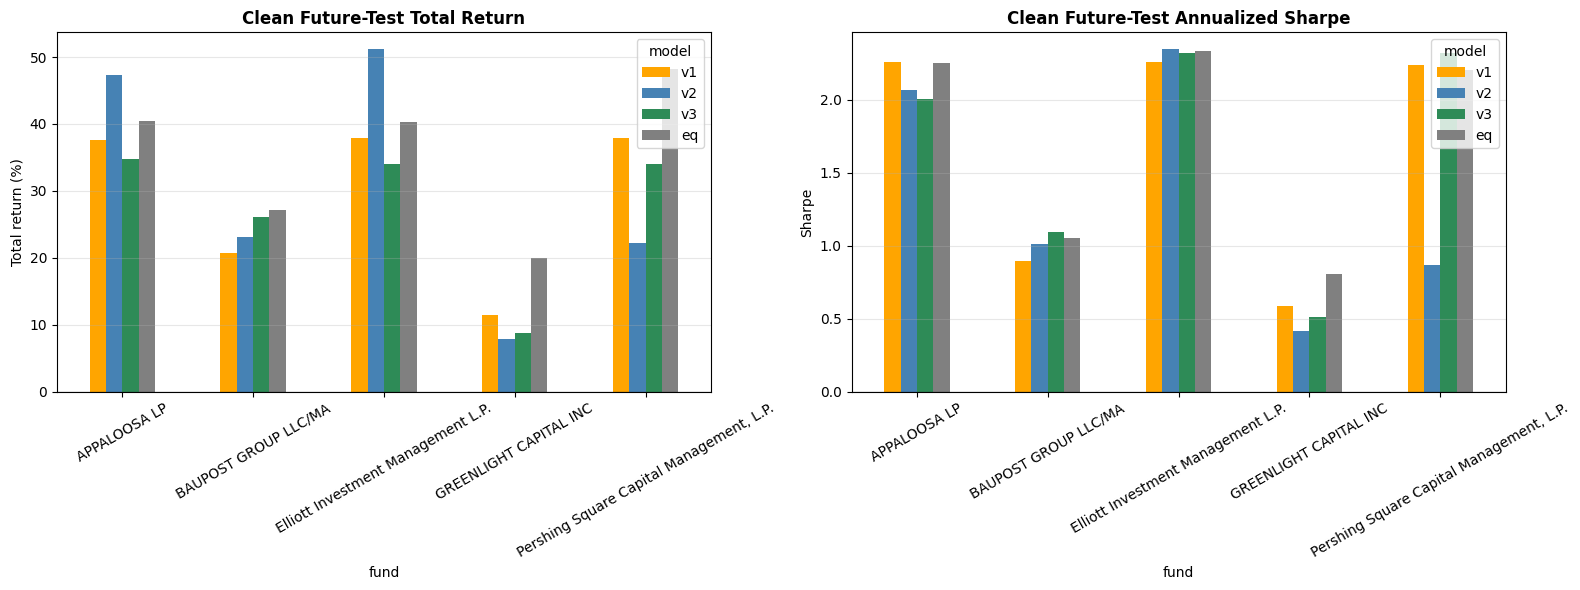

In [23]:
import matplotlib.pyplot as plt

if clean_summary.empty:
    print("No clean results to plot.")
else:
    plot_df = clean_summary.copy()
    order = ["v1", "v2", "v3", "eq"]
    colors = {"v1": "orange", "v2": "steelblue", "v3": "seagreen", "eq": "gray"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ret_wide = plot_df.pivot(index="fund", columns="model", values="total_return").reindex(columns=order) * 100
    ret_wide.plot(kind="bar", ax=axes[0], color=[colors[c] for c in ret_wide.columns])
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Clean Future-Test Total Return", fontweight="bold")
    axes[0].set_ylabel("Total return (%)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(True, alpha=0.3, axis="y")

    shp_wide = plot_df.pivot(index="fund", columns="model", values="ann_sharpe").reindex(columns=order)
    shp_wide.plot(kind="bar", ax=axes[1], color=[colors[c] for c in shp_wide.columns])
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Clean Future-Test Annualized Sharpe", fontweight="bold")
    axes[1].set_ylabel("Sharpe")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


## Wealth Curves

One panel per fund. All curves start at `$1` and use the same clean future test period for that fund.


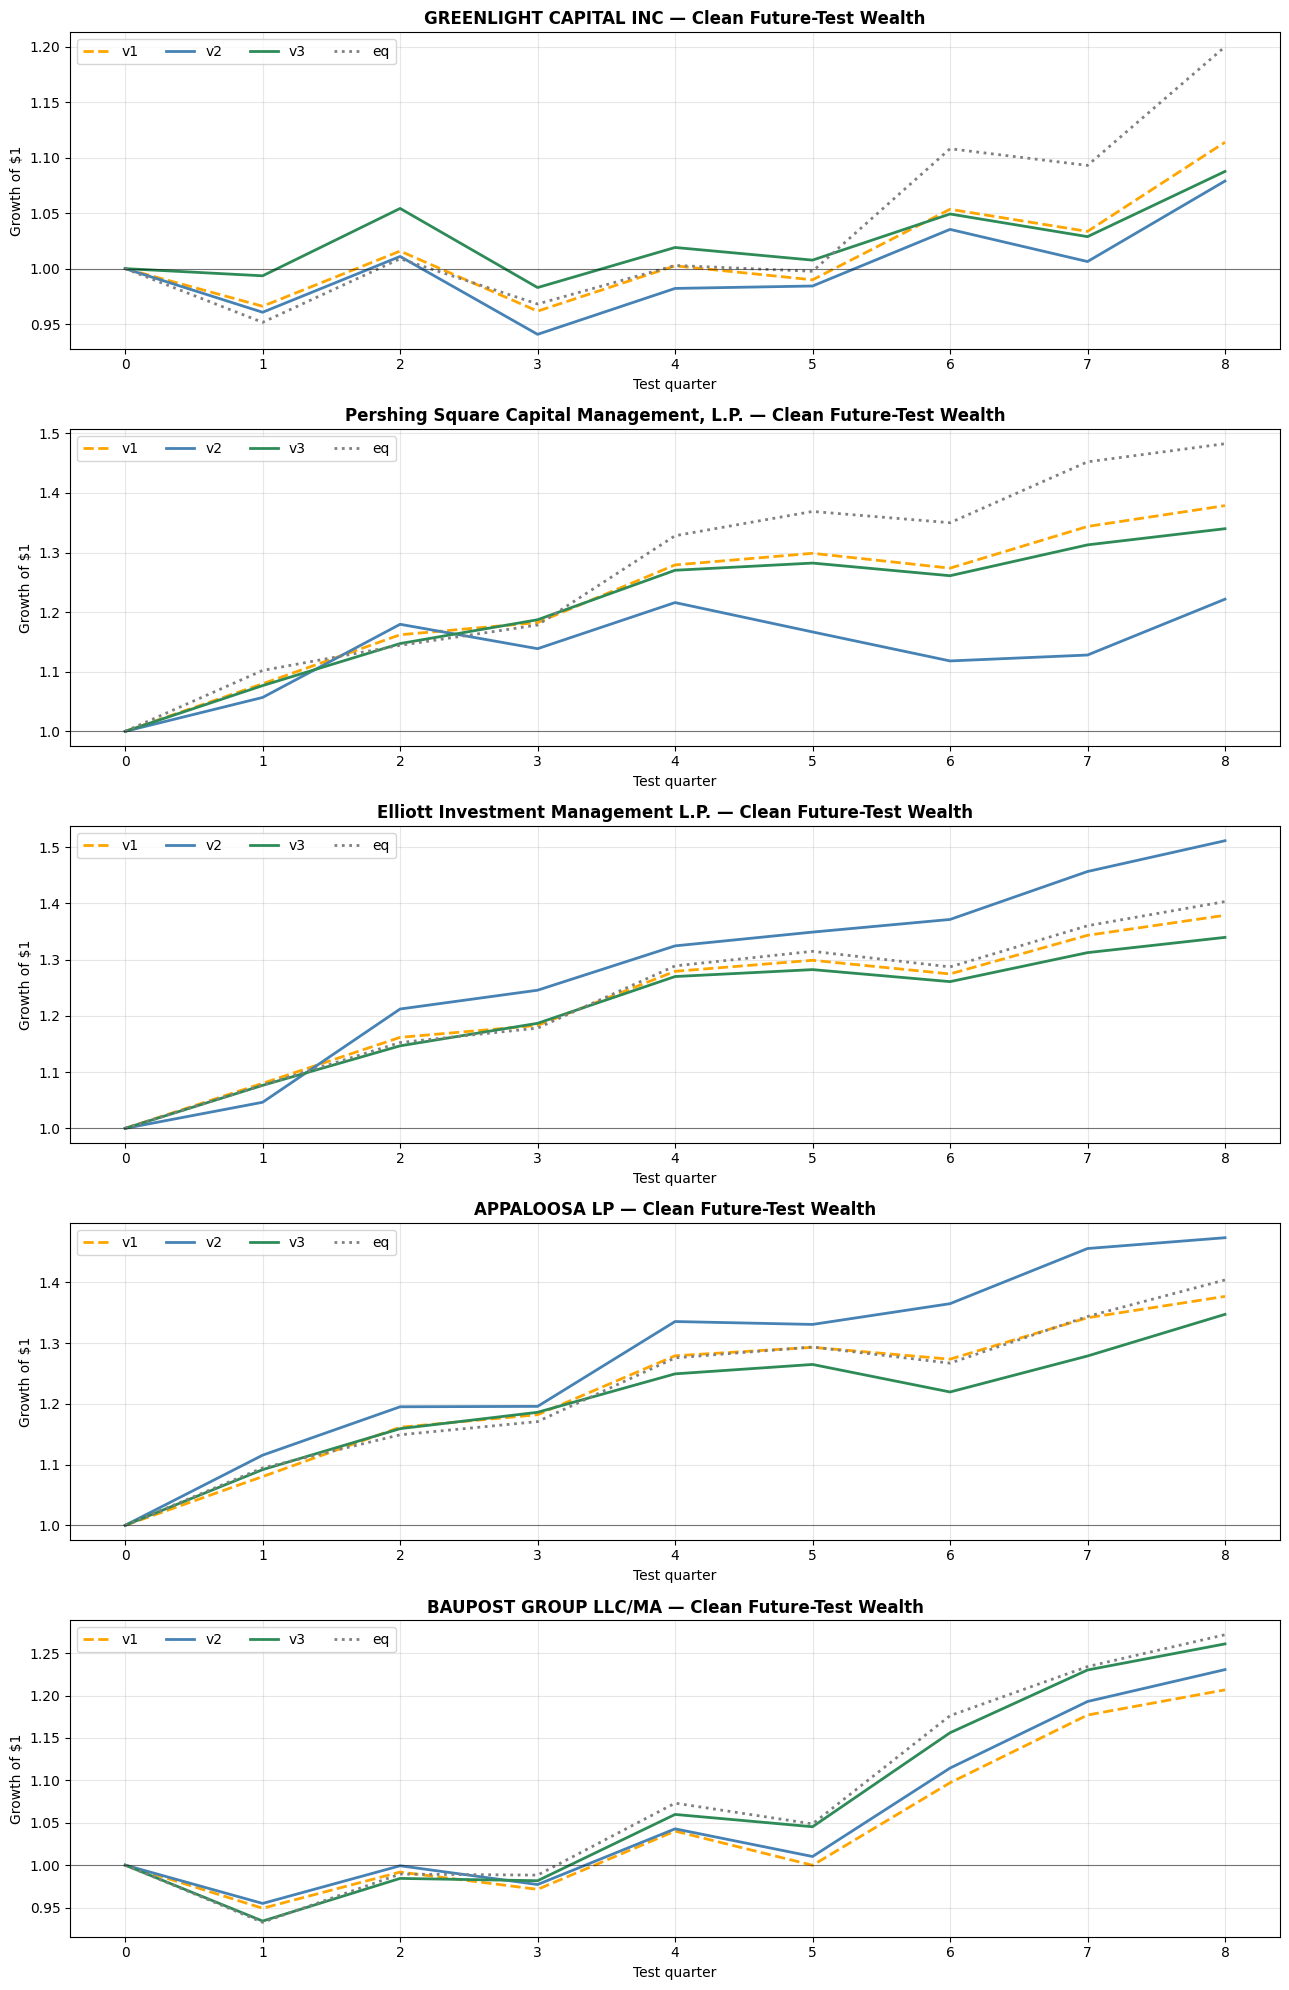

In [24]:
if not clean_multi:
    print("No clean fund results to plot.")
else:
    n = len(clean_multi)
    fig, axes = plt.subplots(n, 1, figsize=(13, 4 * n), squeeze=False)
    colors = {"v1": "orange", "v2": "steelblue", "v3": "seagreen", "eq": "gray"}
    styles = {"v1": "--", "v2": "-", "v3": "-", "eq": ":"}

    for ax, (cik, rec) in zip(axes[:, 0], clean_multi.items()):
        for label in ["v1", "v2", "v3", "eq"]:
            w = rec["results"][label]["wealth"]
            ax.plot(range(len(w)), w, label=label, color=colors[label], linestyle=styles[label], linewidth=2)
        ax.axhline(1.0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(f"{rec['fund'][:45]} — Clean Future-Test Wealth", fontweight="bold")
        ax.set_xlabel("Test quarter")
        ax.set_ylabel("Growth of $1")
        ax.legend(ncol=4)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## V3 Allocation Checks

Shows V3 allocation through the clean future test period and verifies the max sector cap.


GREENLIGHT CAPITAL INC: max V3 sector weight = 0.300  cap = 0.300


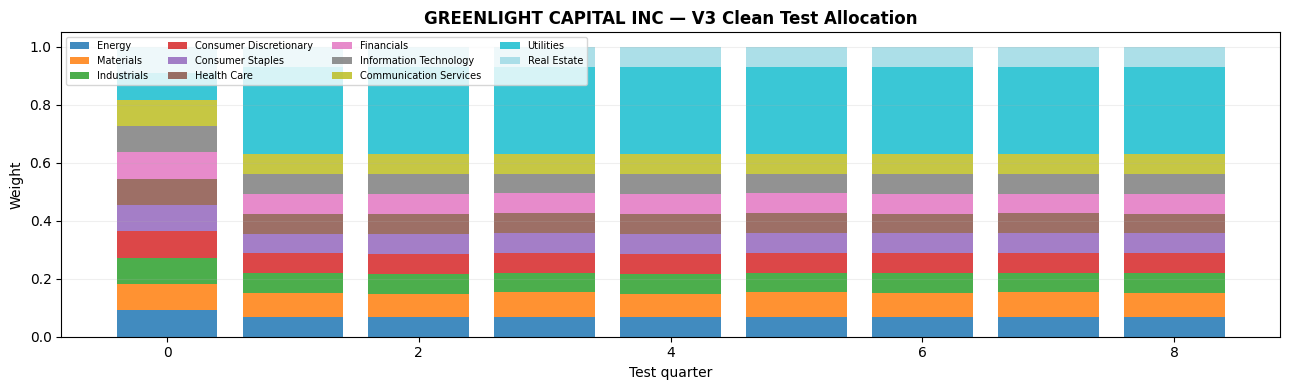

Pershing Square Capital Management, L.P.: max V3 sector weight = 0.300  cap = 0.300


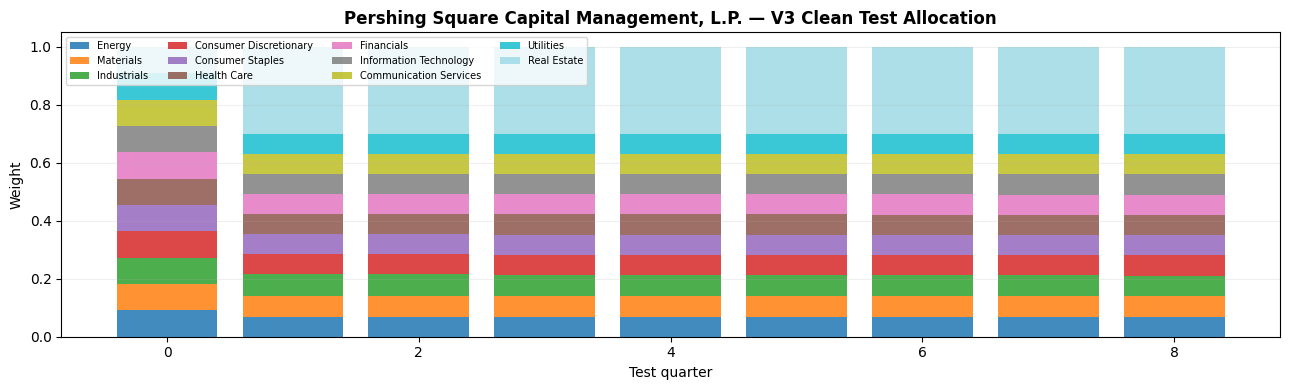

Elliott Investment Management L.P.: max V3 sector weight = 0.300  cap = 0.300


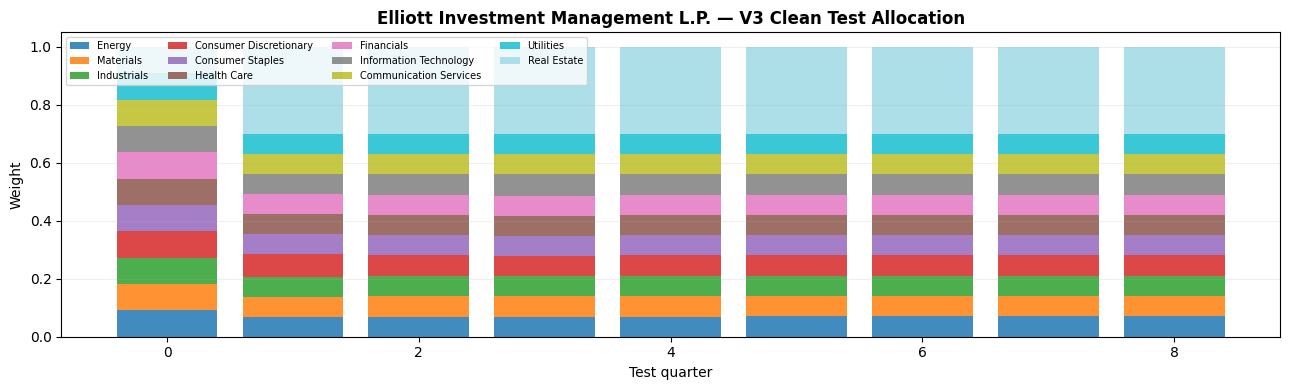

APPALOOSA LP: max V3 sector weight = 0.300  cap = 0.300


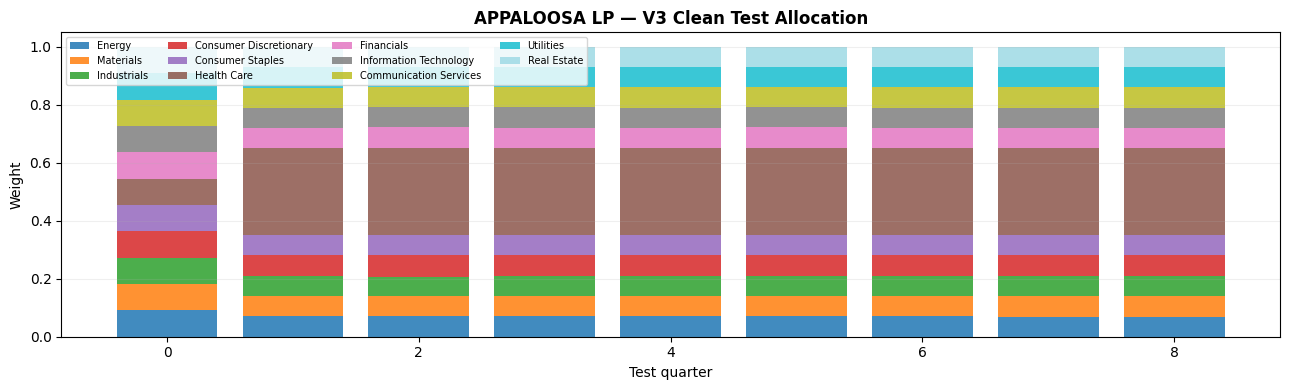

BAUPOST GROUP LLC/MA: max V3 sector weight = 0.300  cap = 0.300


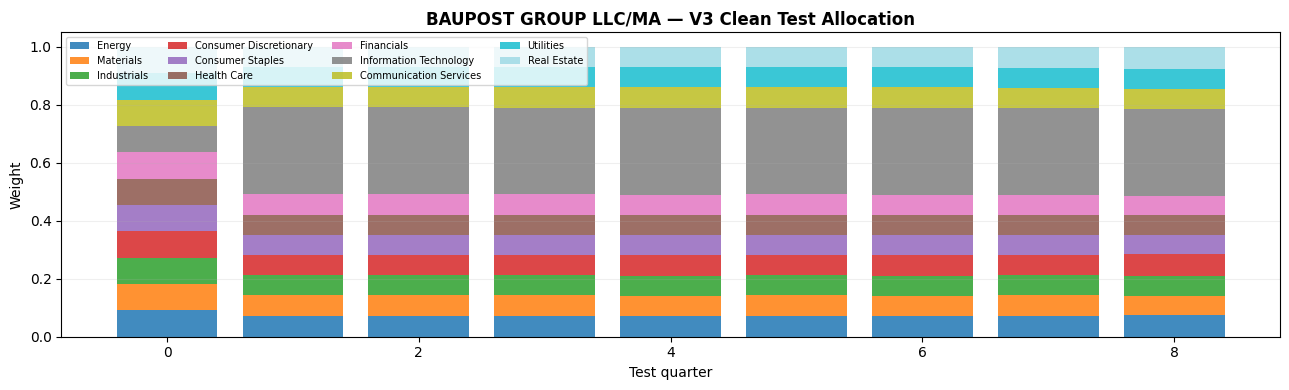

In [25]:
if not clean_multi:
    print("No clean fund results to plot.")
else:
    for cik, rec in clean_multi.items():
        alloc = rec["results"]["v3"]["alloc"]
        sectors = rec["test_traj"]["sectors"]
        max_w = float(np.max(alloc))
        print(f"{rec['fund']}: max V3 sector weight = {max_w:.3f}  cap = {MAX_W_PER_SECTOR:.3f}")

        fig, ax = plt.subplots(figsize=(13, 4))
        bottom = np.zeros(len(alloc))
        colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
        for i, sec in enumerate(sectors):
            ax.bar(range(len(alloc)), alloc[:, i], bottom=bottom, color=colors[i], label=sec, alpha=0.85)
            bottom += alloc[:, i]
        ax.set_title(f"{rec['fund'][:45]} — V3 Clean Test Allocation", fontweight="bold")
        ax.set_xlabel("Test quarter")
        ax.set_ylabel("Weight")
        ax.set_ylim(0, 1.05)
        ax.legend(loc="upper left", fontsize=7, ncol=4)
        ax.grid(True, alpha=0.2, axis="y")
        plt.tight_layout()
        plt.show()


## Clean Rolling Walk-Forward

Separate from the fixed V1/V2/V3 split above. This runs expanding-window V3 only: train on q1..q8, test q9; then train q1..q9, test q10; and so on. IRL, AR(1), and PPO are retrained inside each rolling step using only the current train window.


In [26]:
clean_rolling_rows = []

for fund_idx, f in enumerate(FUNDS):
    cik = f["cik"]
    name = f["name"]

    if cik not in trajs:
        continue

    Tm1 = trajs[cik]["r_t"].shape[0]
    if Tm1 <= ROLLING_START_TRAIN_QUARTERS_CLEAN:
        print(f"\n─── CLEAN ROLLING: {name} skipped, only {Tm1} returns ───")
        continue

    print(f"\n─── CLEAN ROLLING WALK-FORWARD: {name} ───")
    print(f"  train q1..k / test q(k+1), k={ROLLING_START_TRAIN_QUARTERS_CLEAN}..{Tm1 - 1}")

    for k in range(ROLLING_START_TRAIN_QUARTERS_CLEAN, Tm1):
        train_traj_k, test_traj_future = clean_split_traj_no_leakage(trajs[cik], train_end=k)
        test_traj_k = single_step_test_traj(test_traj_future)

        print(f"  rolling step: train returns={k}, test_q={k + 1}")
        params_k, irl_model_k, windows_k, irl_hist_k, irl_summary_k = train_clean_irl(train_traj_k, f"{name} rolling k={k}")
        model_k = train_clean_ppo(
            "v3",
            RobustPortfolioEnv_v3,
            train_traj_k,
            params_k,
            SEED + 10000 * fund_idx + k,
            total_steps=TIMESTEPS_ROLLING_CLEAN,
        )

        wealth, alloc, rets = replay_on_test(model_k, RobustPortfolioEnv_v3, test_traj_k, params_k)
        eq_w, eq_rets = eq_weight_test(test_traj_k)
        port_ret = float(rets[0])
        eq_ret = float(eq_rets[0])

        clean_rolling_rows.append({
            "fund": name,
            "train_end_q": k,
            "test_q": k + 1,
            "port_ret": port_ret,
            "eq_ret": eq_ret,
            "excess_ret": port_ret - eq_ret,
            "wealth": float(wealth[-1]),
            "eq_wealth": float(eq_w[-1]),
            "max_weight": float(np.max(alloc[-1])),
        })

clean_rolling_df = pd.DataFrame(clean_rolling_rows)

if clean_rolling_df.empty:
    print("No clean rolling results completed.")
else:
    print("\n=== CLEAN ROLLING WALK-FORWARD RESULTS ===")
    disp = clean_rolling_df.copy()
    for c in ["port_ret", "eq_ret"]:
        disp[c] = disp[c].map(lambda x: f"{x:+.4f}")
    disp["excess_ret"] = disp["excess_ret"].map(lambda x: f"{x * 100:+.3f}%")
    disp["max_weight"] = disp["max_weight"].map(lambda x: f"{x:.3f}")
    display(disp)



─── CLEAN ROLLING WALK-FORWARD: GREENLIGHT CAPITAL INC ───
  train q1..k / test q(k+1), k=8..15
  rolling step: train returns=8, test_q=9
  IRL train-only for GREENLIGHT CAPITAL INC rolling k=8
  generated 28 windows. Top: 78.76%  Worst: -0.59%
    epoch  100 | loss 154.1115 | rho=0.301 eta=1.603 lambda=0.3094 w=0.3862 alpha=1.126
    epoch  200 | loss 146.5863 | rho=0.300 eta=1.608 lambda=0.1624 w=0.2738 alpha=1.069
    epoch  300 | loss 145.3352 | rho=0.300 eta=1.607 lambda=0.1126 w=0.3023 alpha=1.088
    epoch  400 | loss 144.5353 | rho=0.300 eta=1.607 lambda=0.0810 w=0.3250 alpha=1.104
    epoch  500 | loss 144.0206 | rho=0.300 eta=1.607 lambda=0.0606 w=0.3386 alpha=1.114
    epoch  600 | loss 143.6775 | rho=0.300 eta=1.607 lambda=0.0469 w=0.3476 alpha=1.120
    epoch  700 | loss 143.4388 | rho=0.300 eta=1.606 lambda=0.0375 w=0.3538 alpha=1.125
    epoch  800 | loss 143.2663 | rho=0.300 eta=1.606 lambda=0.0306 w=0.3582 alpha=1.128
    epoch  900 | loss 143.1374 | rho=0.300 eta=1.6

,fund,train_end_q,test_q,port_ret,eq_ret,excess_ret,wealth,eq_wealth,max_weight
0,GREENLIGHT CAPITAL INC,8,9,-0.0353,-0.0484,+1.313%,0.964695,0.951561,0.093
1,GREENLIGHT CAPITAL INC,9,10,+0.0535,+0.0603,-0.677%,1.053478,1.060253,0.092
2,GREENLIGHT CAPITAL INC,10,11,-0.0518,-0.0404,-1.132%,0.948237,0.959558,0.092
3,GREENLIGHT CAPITAL INC,11,12,+0.0430,+0.0359,+0.713%,1.043027,1.035895,0.093
4,GREENLIGHT CAPITAL INC,12,13,-0.0159,-0.0052,-1.069%,0.984072,0.994761,0.101
...,...,...,...,...,...,...,...,...,...
57,BAUPOST GROUP LLC/MA,13,14,+0.0886,+0.0859,+0.265%,1.088556,1.085907,0.300
58,BAUPOST GROUP LLC/MA,14,15,-0.0446,-0.0228,-2.181%,0.955374,0.977180,0.300
59,BAUPOST GROUP LLC/MA,15,16,+0.0869,+0.1217,-3.482%,1.086914,1.121738,0.300
60,BAUPOST GROUP LLC/MA,16,17,+0.0781,+0.0492,+2.892%,1.078079,1.049161,0.300


## Clean Rolling Summary And Plots

Per-fund rolling excess-return statistics and per-step plots. These are the visuals for Nuohan's rolling walk-forward point.


,fund,n_test,roll_v3_ret,roll_eq_ret,mean_excess_pct,median_excess_pct,win_rate_pct,rolling_sharpe
0,APPALOOSA LP,15.0,+30.87%,+49.83%,-0.91%,-0.70%,26.67%,-0.994
1,BAUPOST GROUP LLC/MA,10.0,+20.40%,+20.08%,-0.03%,-0.58%,30.00%,-0.018
2,Elliott Investment Management L.P.,14.0,+34.83%,+54.16%,-0.98%,-1.44%,21.43%,-1.549
3,GREENLIGHT CAPITAL INC,8.0,+12.17%,+20.01%,-0.91%,-0.87%,37.50%,-1.022
4,"Pershing Square Capital Management, L.P.",15.0,+46.05%,+32.31%,0.44%,-0.57%,46.67%,0.201


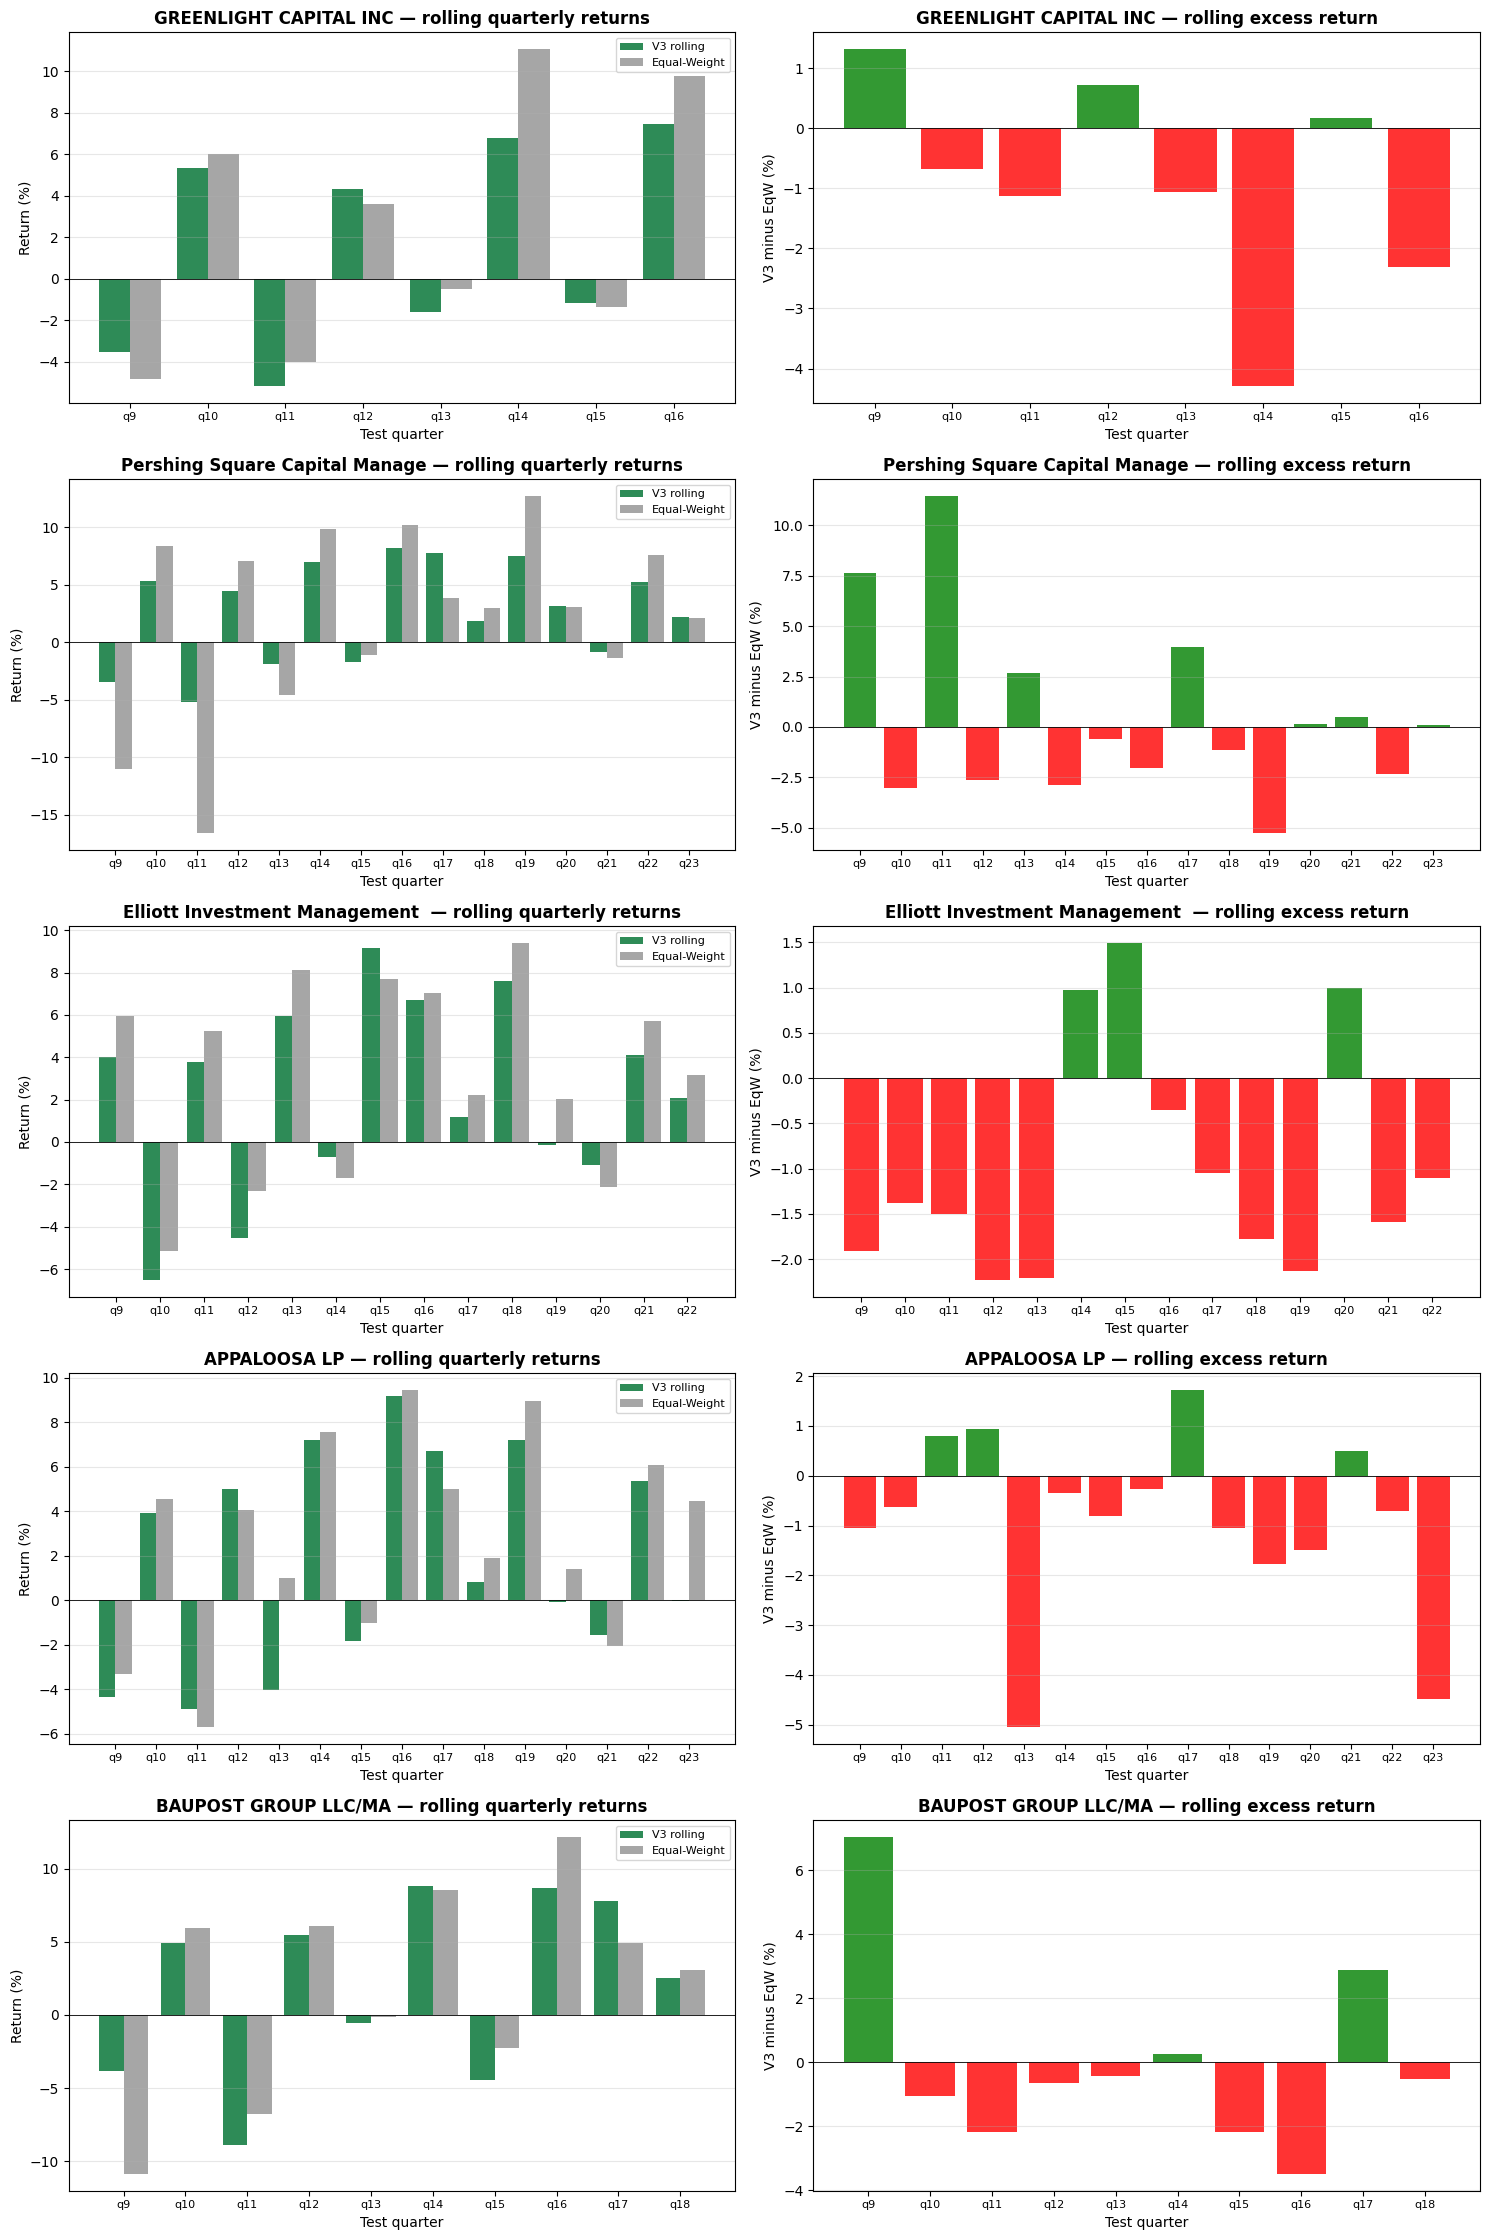

In [27]:
if "clean_rolling_df" not in globals() or clean_rolling_df.empty:
    print("Run the Clean Rolling Walk-Forward cell first.")
else:
    def _rolling_stats(g):
        er = g["excess_ret"].values
        return pd.Series({
            "n_test": len(g),
            "roll_v3_ret": np.prod(1.0 + g["port_ret"].values) - 1.0,
            "roll_eq_ret": np.prod(1.0 + g["eq_ret"].values) - 1.0,
            "mean_excess_pct": er.mean() * 100,
            "median_excess_pct": np.median(er) * 100,
            "win_rate_pct": (er > 0).mean() * 100,
            "rolling_sharpe": sharpe_from_rets(er),
        })

    rolling_summary = clean_rolling_df.groupby("fund").apply(_rolling_stats).reset_index()
    rolling_summary_display = rolling_summary.copy()
    for c in ["roll_v3_ret", "roll_eq_ret"]:
        rolling_summary_display[c] = rolling_summary_display[c].map(lambda x: f"{x:+.2%}")
    for c in ["mean_excess_pct", "median_excess_pct", "win_rate_pct"]:
        rolling_summary_display[c] = rolling_summary_display[c].map(lambda x: f"{x:.2f}%")
    rolling_summary_display["rolling_sharpe"] = rolling_summary_display["rolling_sharpe"].map(lambda x: "—" if pd.isna(x) else f"{x:.3f}")
    display(rolling_summary_display)

    funds_in = clean_rolling_df["fund"].unique()
    fig, axes = plt.subplots(len(funds_in), 2, figsize=(15, 4.5 * len(funds_in)), squeeze=False)

    for i, fund_name in enumerate(funds_in):
        sub = clean_rolling_df[clean_rolling_df["fund"] == fund_name].sort_values("train_end_q")
        x = np.arange(len(sub))
        test_qs = sub["test_q"].values
        port_pct = sub["port_ret"].values * 100
        eq_pct = sub["eq_ret"].values * 100
        excess_pct = sub["excess_ret"].values * 100

        ax = axes[i, 0]
        width = 0.4
        ax.bar(x - width / 2, port_pct, width, label="V3 rolling", color="seagreen")
        ax.bar(x + width / 2, eq_pct, width, label="Equal-Weight", color="gray", alpha=0.7)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title(f"{fund_name[:30]} — rolling quarterly returns", fontweight="bold")
        ax.set_xlabel("Test quarter")
        ax.set_ylabel("Return (%)")
        ax.set_xticks(x)
        ax.set_xticklabels([f"q{q}" for q in test_qs], fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

        ax = axes[i, 1]
        colors = ["green" if e >= 0 else "red" for e in excess_pct]
        ax.bar(x, excess_pct, color=colors, alpha=0.8)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title(f"{fund_name[:30]} — rolling excess return", fontweight="bold")
        ax.set_xlabel("Test quarter")
        ax.set_ylabel("V3 minus EqW (%)")
        ax.set_xticks(x)
        ax.set_xticklabels([f"q{q}" for q in test_qs], fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


## Save Results

Optional export of the clean summary table.


In [28]:
if clean_summary.empty:
    print("No clean summary to save.")
else:
    clean_summary.to_csv("clean_no_leakage_summary.csv", index=False)
    print("Saved clean_no_leakage_summary.csv")
    if "clean_rolling_df" in globals() and not clean_rolling_df.empty:
        clean_rolling_df.to_csv("clean_no_leakage_rolling.csv", index=False)
        print("Saved clean_no_leakage_rolling.csv")


Saved clean_no_leakage_summary.csv
Saved clean_no_leakage_rolling.csv
